In [1]:
# NOTE:
#  - this NB aims to model an observed source with bm
#  - here there is an improved version of the optimiser
#  - this is the same as `demo_sources_ebands_fit_benchmrk`, but in the full eband [2.0, 50.0] keV

# NOTE: this NB TESTS the efficiency of the FLEXIBLE implementations for SOURCE MODEL and IROS

from singleCAM_IROS._pipeline_support import _handle_dirpaths
from typing import Callable, Iterable
from pathlib import Path

from tqdm import tqdm
from numpy.typing import NDArray
import numpy as np
from astropy.io.fits.fitsrec import FITS_rec

from bloodmoon.coords import shift2pos
from bloodmoon.io import simulation_files
from bloodmoon.mask import CodedMaskCamera, codedmask
from bloodmoon.mask import count

import darksun as ds

from flexible_IROS_rec_procedure import Source
from flexible_IROS_rec_procedure import iros_singleCAM
from flexible_source_model import model_shadowgram, model_sky


ds.show.set_figures_darkbkg()

In [2]:
def config_psfy_flag(dataset: str) -> bool:
    if dataset not in ['detected', 'reconstructed']:
        raise ValueError('Invalid dataset type.')
    flag: bool = (True if DATASET == 'reconstructed' else False)
    return flag

MASK_FITS: str = "wfm_mask_NTHT_20250725.fits"

SKYFIELD: str = "IROSDummy"
DATA_FITS: str = "iros_benchmark_2-50keV_mask_050_1040x17_infdet_1ks"

ID_CAMERA_A: str = "cam1a"
DATASET: str = "reconstructed"

UPS_X: int = 2
UPS_Y: int = 1

VIGNETTING: bool = True
PSFY: bool = config_psfy_flag(DATASET)

In [3]:
# load filepaths
mask_path, simul_data, save_path = _handle_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
)
wfm: CodedMaskCamera = codedmask(mask_path, UPS_X, UPS_Y)
filepaths: dict[str, dict[str, Path]] = simulation_files(simul_data)

# data from camera A
sdlA = ds.get_data(filepaths[ID_CAMERA_A][DATASET])

In [4]:
def _crop_inoptim(camera: CodedMaskCamera) -> tuple[int, int]:
    slit_fine, slit_coarse = ds.psf_extension(camera)
    crp = (
        slit_coarse + 5 * camera.upscale_f.y,
        slit_fine + 2 + camera.upscale_f.x,
    )
    return crp

PSF_CRP = _crop_inoptim(wfm)


def run(loop: Iterable) -> tuple[Source, ...]:
    """Runs the IROS loop."""
    print("# Running IROS loop...")
    candidates = tuple(cand for cand, _ in tqdm(loop))
    print("# End IROS loop...\n")
    return candidates

def plot_results(
    true_sky: NDArray,
    candidates: tuple[Source, ...],
    camera: CodedMaskCamera,
    varmap: NDArray | None = None,
    save_to: str | Path | None = None,
) -> None:
    """Plots energy band IROS results."""
    true_sky_ = true_sky.copy()
    std = np.sqrt(varmap)
    res_ground = np.zeros_like(true_sky_)
    for idx, cand in enumerate(candidates):
        pos: tuple[int, int] = shift2pos(camera, cand.shift_x, cand.shift_y)
        modeled: NDArray = model_sky(
            camera, cand.shift_x, cand.shift_y, cand.cts, VIGNETTING, PSFY,
        )
        sourceID: str = f'run_s{idx}'
        ds.slices_plot(
            sky=(true_sky_, modeled),
            pos=pos,
            crp=PSF_CRP,
            ylabel='counts [ph]',
            labels=('true', 'IROS'),
            color=('Orange', 'DeepSkyBlue'),
            source=sourceID,
            save_to=(
                ds.savefile_to(save_to, f'{sourceID.upper()}_profile')
                if save_to is not None else None
            ),
        )
        ds.slices_plot(
            sky=(res_ground, true_sky_ - modeled, std),
            pos=pos,
            crp=PSF_CRP,
            ylabel='residues',
            labels=['', 'true - IROS', 'local sigma'],
            color=('Orange', 'DeepSkyBlue', 'm'),
            source=sourceID,
            save_to=(
                ds.savefile_to(save_to, f'{sourceID.upper()}_profile_res')
                if save_to is not None else None
            ),
        )
        true_sky_ -= modeled

    return None

In [5]:
from scipy.signal import convolve
from vignetting_mask_newArch import apply_std_vignetting

type EnergyRange = tuple[float, float]

def filter_energy(
    photons: FITS_rec,
    eband: EnergyRange,
) -> FITS_rec:
    """Filters the input photons by energy, in [keV]."""
    E_min, E_max = eband
    return ds.filter_data(photons, E_min=E_min, E_max=E_max, coords=None)


def config_psfy_func(
    eband: EnergyRange,
    sampling: int = 10_000,
) -> Callable[[CodedMaskCamera, NDArray], NDArray]:
    """
    Configures detector spatial resolution effect.
    """
    def take_int_average(x: NDArray, y: NDArray) -> float:
        """Performs the integral mean of `y` wrt input `x` values."""
        return np.sum(y[:-1] * np.diff(x)) / (x[-1] - x[0])
    
    def alpha_model(energy: NDArray, a: float, b: float, c: float) -> NDArray:
        """Model for PSFY kernel alpha parameter."""
        pred = a * np.exp(-np.pow(b * (energy - 2), c))
        return pred
    
    def compute_psfy_kernel(x: NDArray, alpha: float, beta: float) -> NDArray:
        """Computes detector spatial resolution kernel from input params."""
        modsec = 1.0 / np.cosh(np.abs(x / alpha) ** beta)
        psfy = modsec.reshape(len(x), -1)
        return psfy / np.sum(psfy)

    def apply_detector_resolution(
        camera: CodedMaskCamera,
        shadowgram: NDArray,
    ) -> NDArray:
        """
        Applies finite detector spatial resolution effects to a shadowgram.
        """
        # define parameters
        x = np.log(np.logspace(*eband, sampling, base=np.e))
        ALPHA_PARAMS = {
            'a': 1.2702015,
            'b': 0.1901737,
            'c': 0.6711220,
        }
        KERNEL_PARAMS = {
            'alpha': take_int_average(x, alpha_model(x, **ALPHA_PARAMS)),
            'beta': 0.85,
        }
        # compute PSFY kernel
        px_ydim = camera.specs.mask_deltay / camera.upscale_f.y
        slit_dim = camera.specs.slit_deltay
        bins = np.linspace(-slit_dim, slit_dim, int(2 * slit_dim / px_ydim) + 1)
        kernel = compute_psfy_kernel(bins, **KERNEL_PARAMS)

        return convolve(shadowgram, kernel, mode="same")
    
    return apply_detector_resolution

In [6]:
def comp_fit_weights(obs: NDArray) -> NDArray:
    """Computes the weights for the loss metric in the optimisation procedure."""
    return 1.0 / np.sqrt(np.clip(obs, a_min=1.0, a_max=None))


max_iterations: int = 10
snr_threshold: float = 5.0
fit_weights: NDArray | Callable | None = comp_fit_weights

eband: EnergyRange = (2.0, 3.0)  # [keV]

VIGNETTING: bool | Callable = apply_std_vignetting
PSFY: bool | Callable = config_psfy_func(eband)

eband_phs: FITS_rec = filter_energy(sdlA.DLdata, eband)
detector: NDArray = count(wfm, eband_phs)[0]

## USING BULK MASK with 1.5 mm cover ##


In [7]:
iros_loop = iros_singleCAM(
    detector=detector,
    camera=wfm,
    max_iterations=max_iterations,
    vignetting=VIGNETTING,
    psfy=PSFY,
    fit_weights=fit_weights,
)
candidates: tuple[Source, ...] = run(iros_loop)

# Running IROS loop...


1it [00:05,  5.54s/it]

## Optimisation Results:
  * p[0]:
      - START.: -108.3750000
      - OPTIM.: -108.4146513 +/- 0.0000661
      - GAIN.: -0.037 %
  * p[1]:
      - START.: 62.5000000
      - OPTIM.: 62.6468814 +/- 0.0030501
      - GAIN.: 0.235 %
  * p[2]:
      - START.: 115083.0585669
      - OPTIM.: 110373.0536848 +/- 32.3488498
      - GAIN.: -4.093 %

## Fit Report:
  - func calls (also # of iters): 6
  - procedure msg: `ftol` termination condition is satisfied.
  - success status 2: Convergence in parameter values



2it [00:10,  5.24s/it]

## Optimisation Results:
  * p[0]:
      - START.: -84.2500000
      - OPTIM.: -84.2479319 +/- 0.0002214
      - GAIN.: 0.002 %
  * p[1]:
      - START.: -38.5000000
      - OPTIM.: -38.7157039 +/- 0.0144721
      - GAIN.: -0.560 %
  * p[2]:
      - START.: 31965.6150236
      - OPTIM.: 31464.5360308 +/- 40.2892878
      - GAIN.: -1.568 %

## Fit Report:
  - func calls (also # of iters): 6
  - procedure msg: `ftol` termination condition is satisfied.
  - success status 2: Convergence in parameter values



...

## Optimisation Results:
  * p[0]:
      - START.: -138.1250000
      - OPTIM.: -138.2262489 +/- 0.0005269
      - GAIN.: -0.073 %
  * p[1]:
      - START.: -56.0000000
      - OPTIM.: -56.5000000 +/- 0.0240916
      - GAIN.: -0.893 %
  * p[2]:
      - START.: 12752.0296054
      - OPTIM.: 12352.5450743 +/- 29.2263036
      - GAIN.: -3.133 %

## Fit Report:
  - func calls (also # of iters): 14
  - procedure msg: `xtol` termination condition is satisfied.
  - success status 3: Convergence in both chi-square and parameter values



9it [01:00,  7.60s/it]

## Optimisation Results:
  * p[0]:
      - START.: 55.7500000
      - OPTIM.: 55.8088878 +/- 0.0007519
      - GAIN.: 0.106 %
  * p[1]:
      - START.: 21.0000000
      - OPTIM.: 21.3889107 +/- 0.0460009
      - GAIN.: 1.852 %
  * p[2]:
      - START.: 12410.7412219
      - OPTIM.: 13186.4125482 +/- 58.2907965
      - GAIN.: 6.250 %

## Fit Report:
  - func calls (also # of iters): 9
  - procedure msg: Both `ftol` and `xtol` termination conditions are satisfied.
  - success status 4: Convergence in orthogonality



10it [01:05,  6.57s/it]

## Optimisation Results:
  * p[0]:
      - START.: -49.0000000
      - OPTIM.: -48.9857717 +/- 0.0010493
      - GAIN.: 0.029 %
  * p[1]:
      - START.: -56.0000000
      - OPTIM.: -56.1433374 +/- 0.0655636
      - GAIN.: -0.256 %
  * p[2]:
      - START.: 10632.0096539
      - OPTIM.: 10762.6892938 +/- 64.6652721
      - GAIN.: 1.229 %

## Fit Report:
  - func calls (also # of iters): 6
  - procedure msg: `ftol` termination condition is satisfied.
  - success status 2: Convergence in parameter values

# End IROS loop...



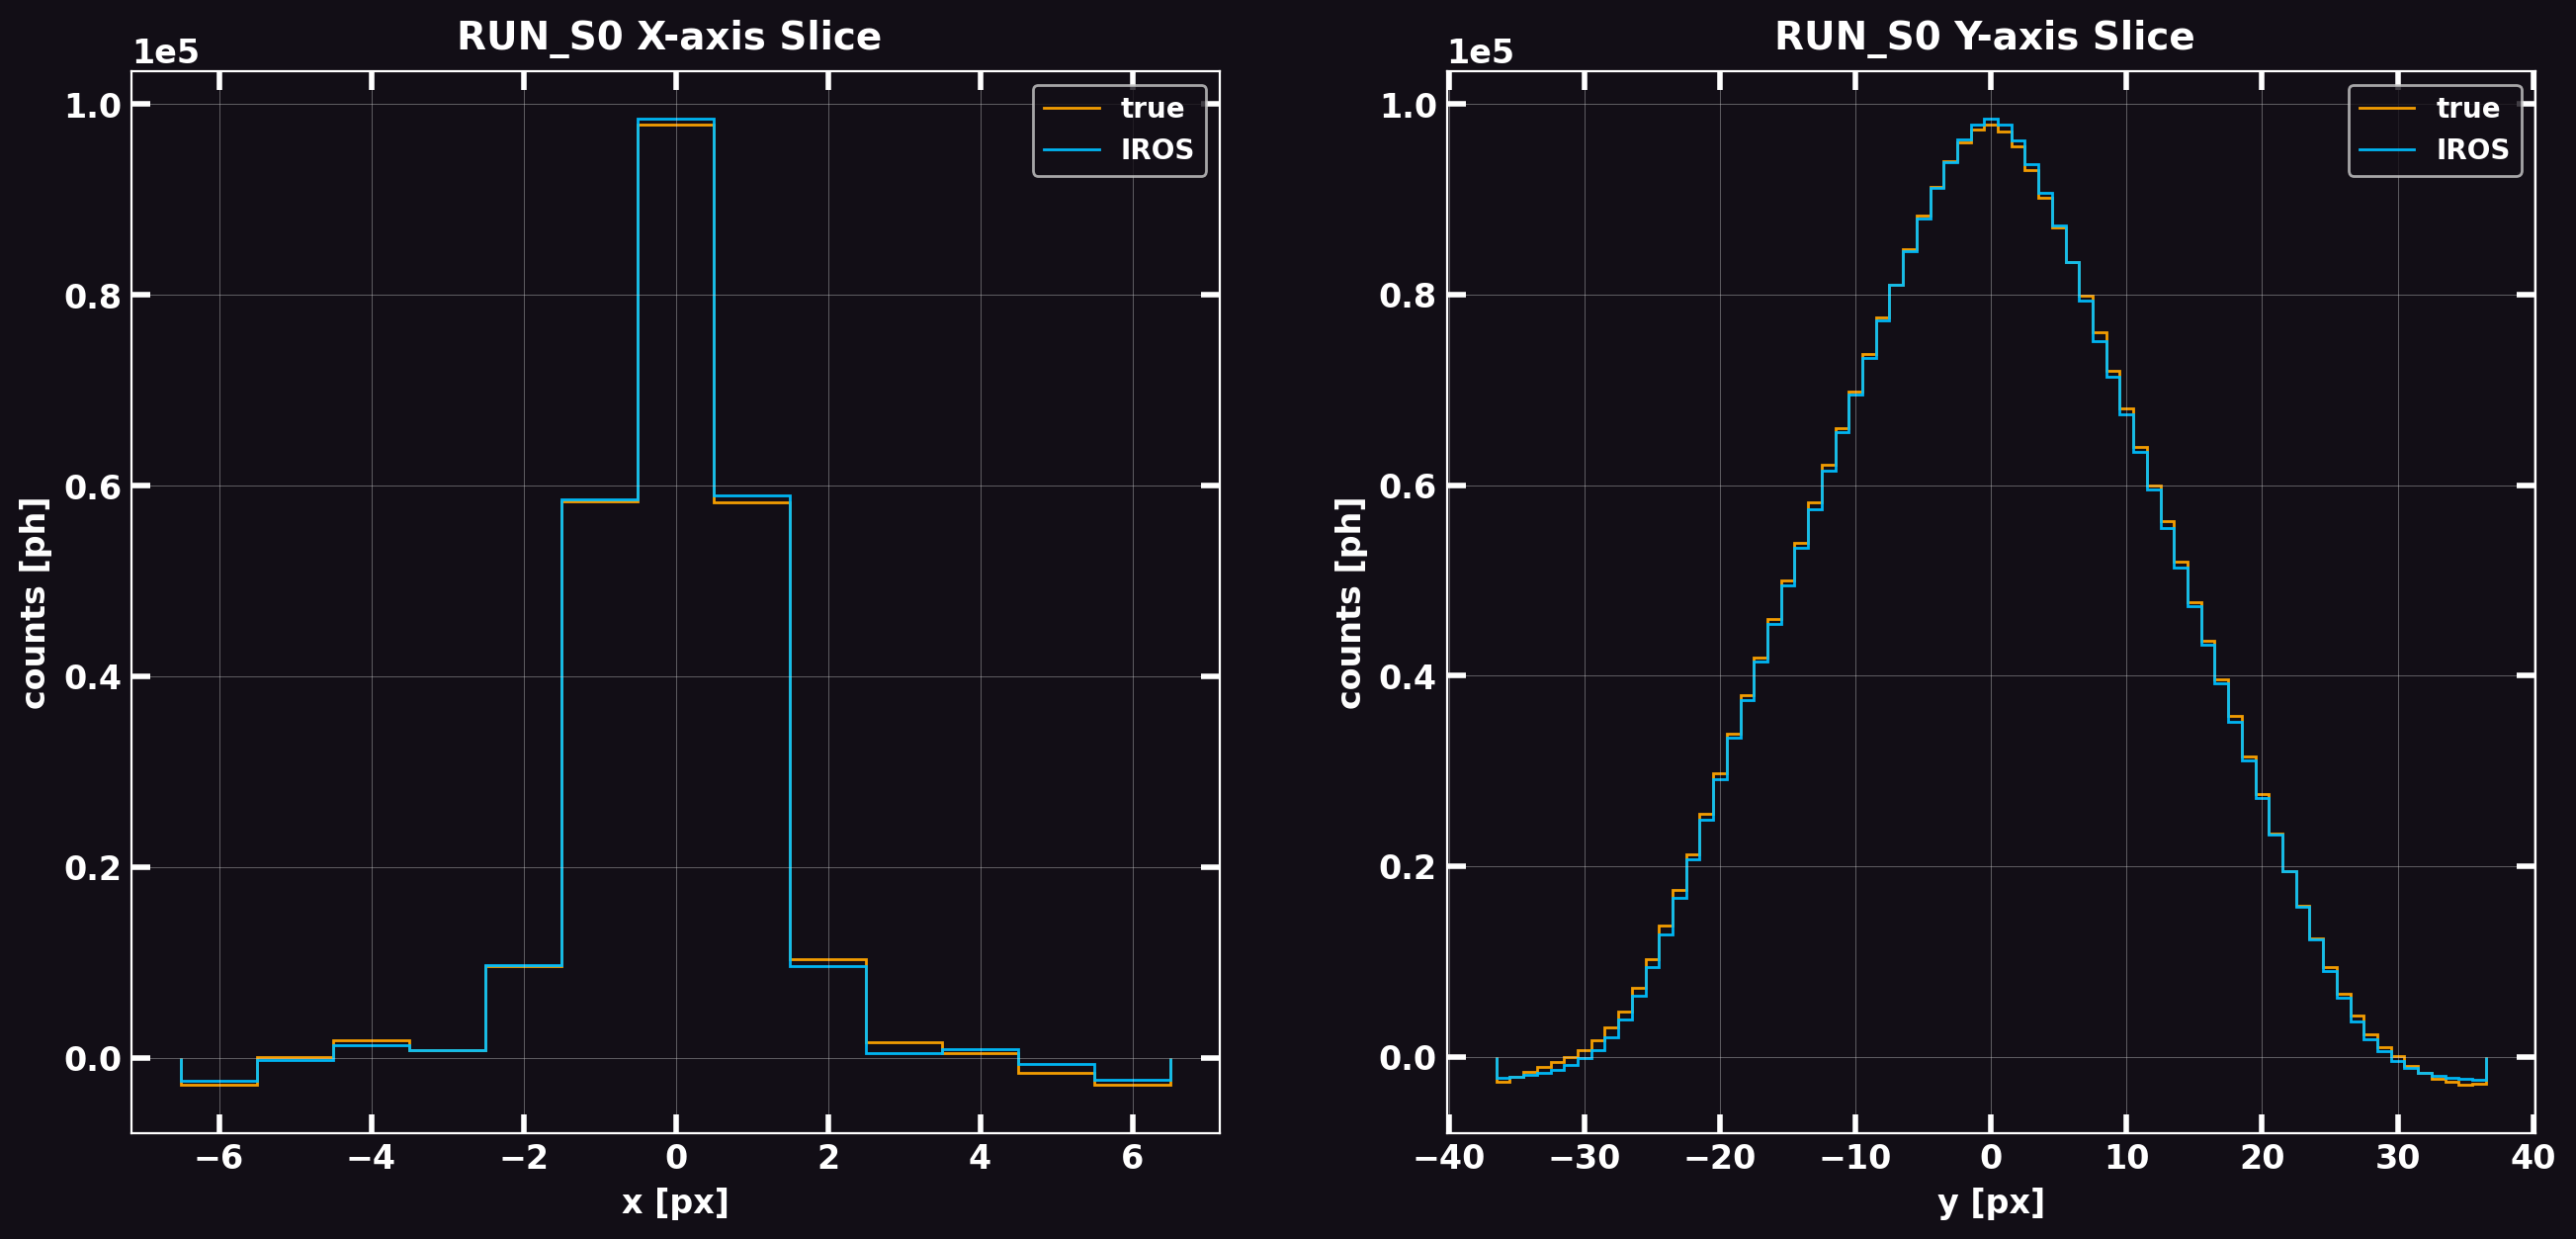

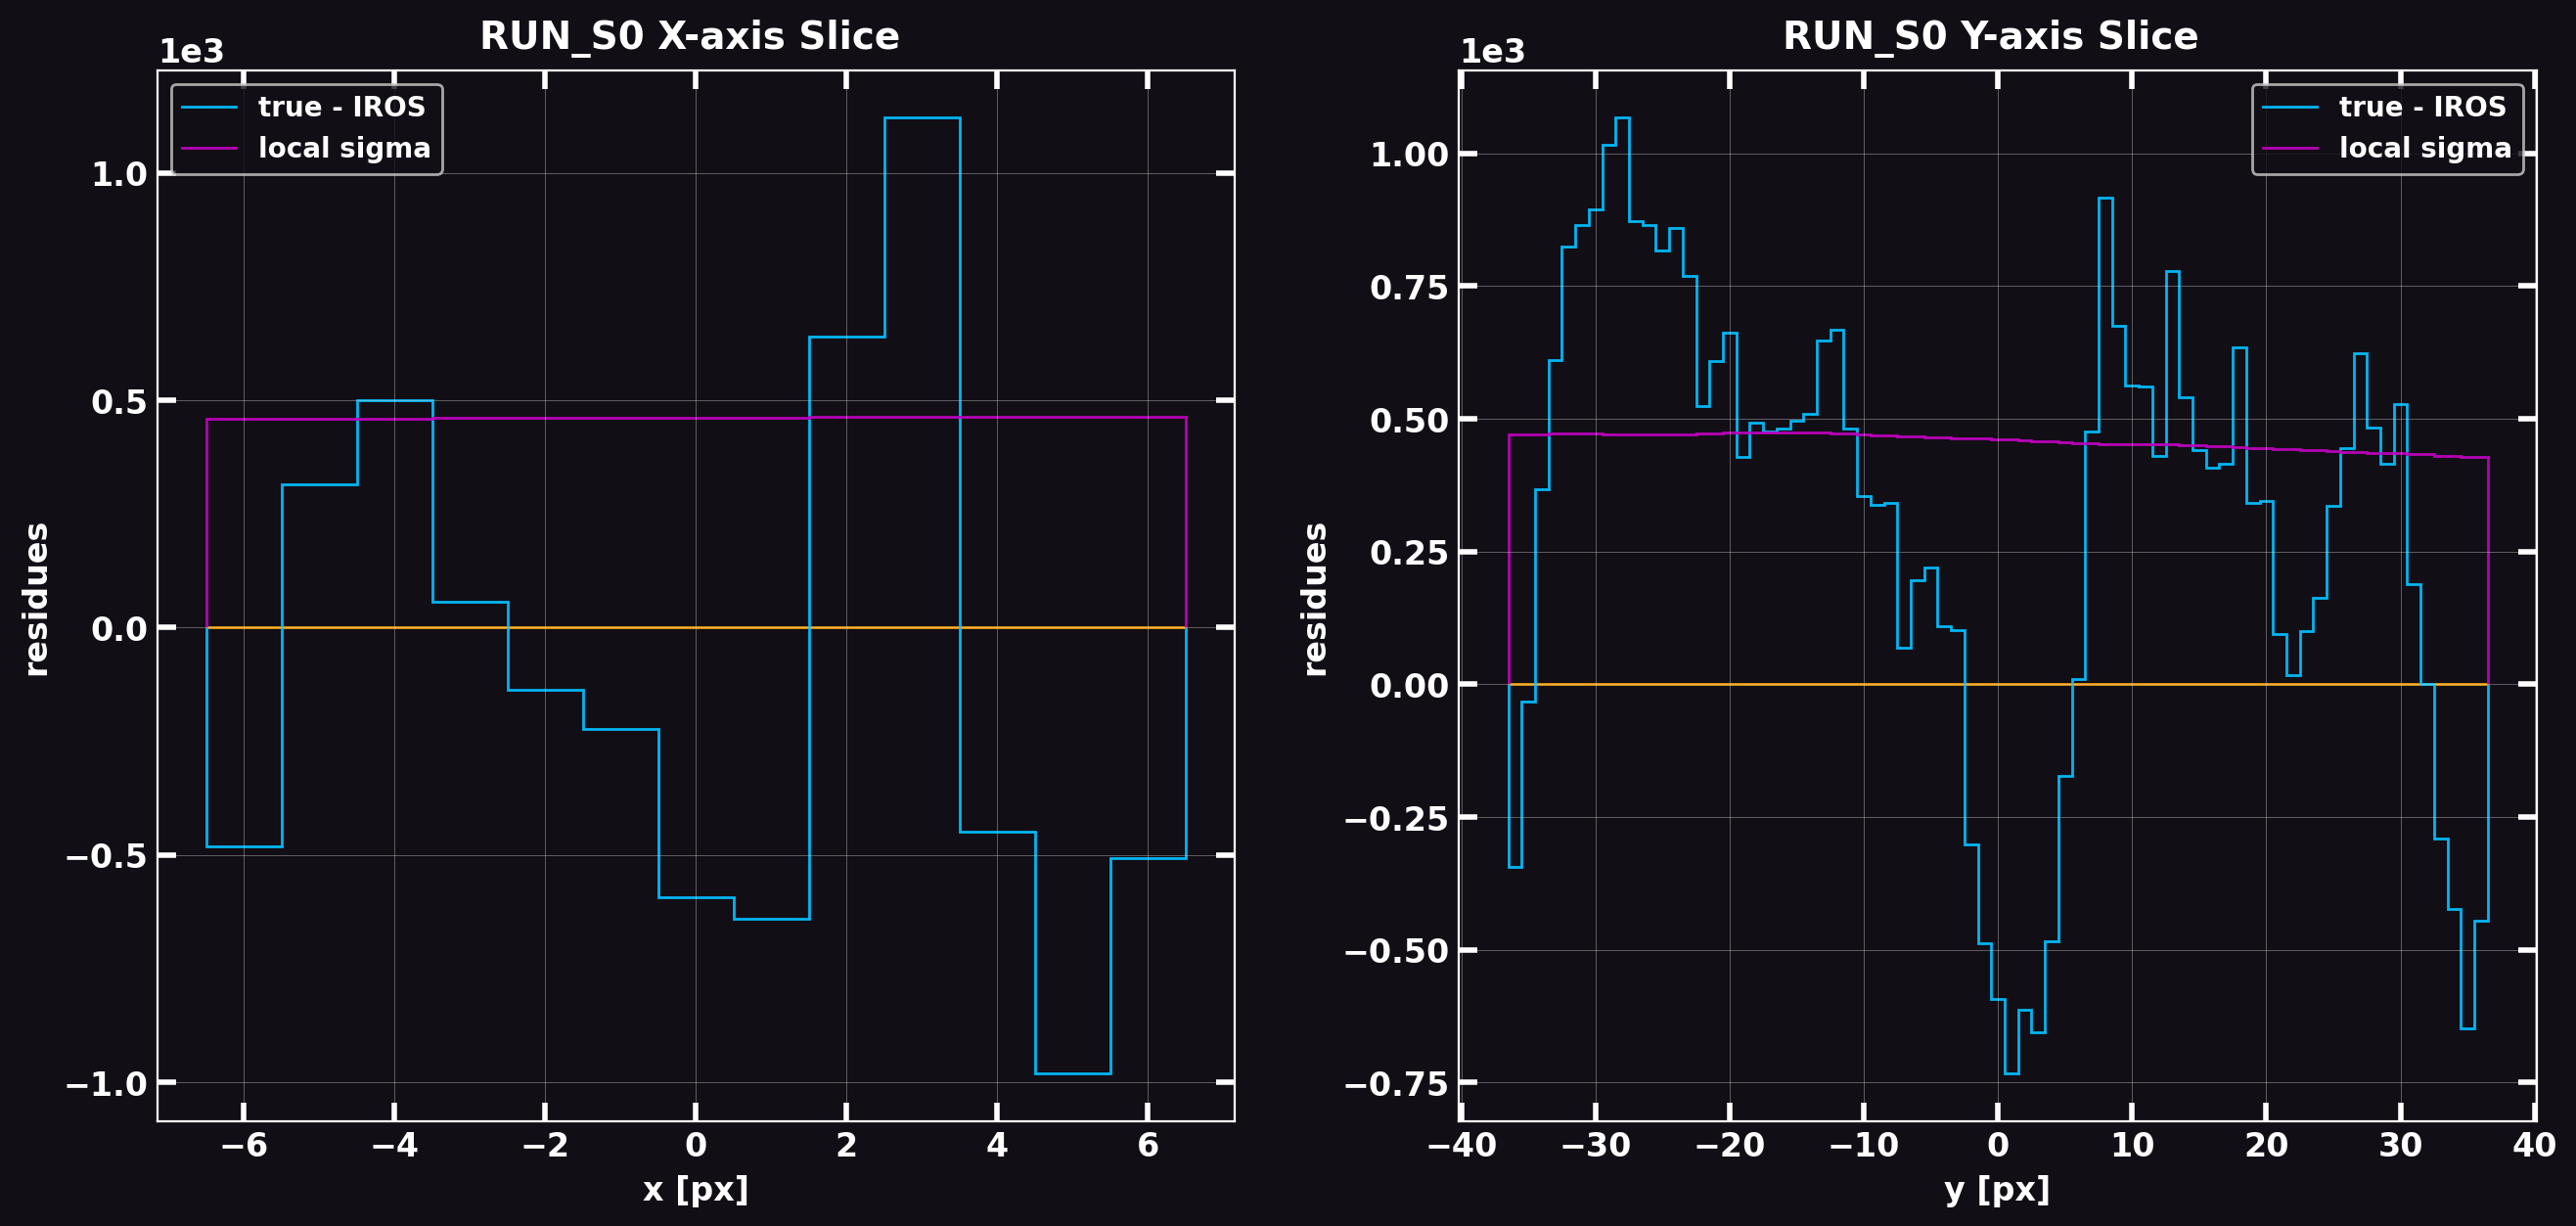

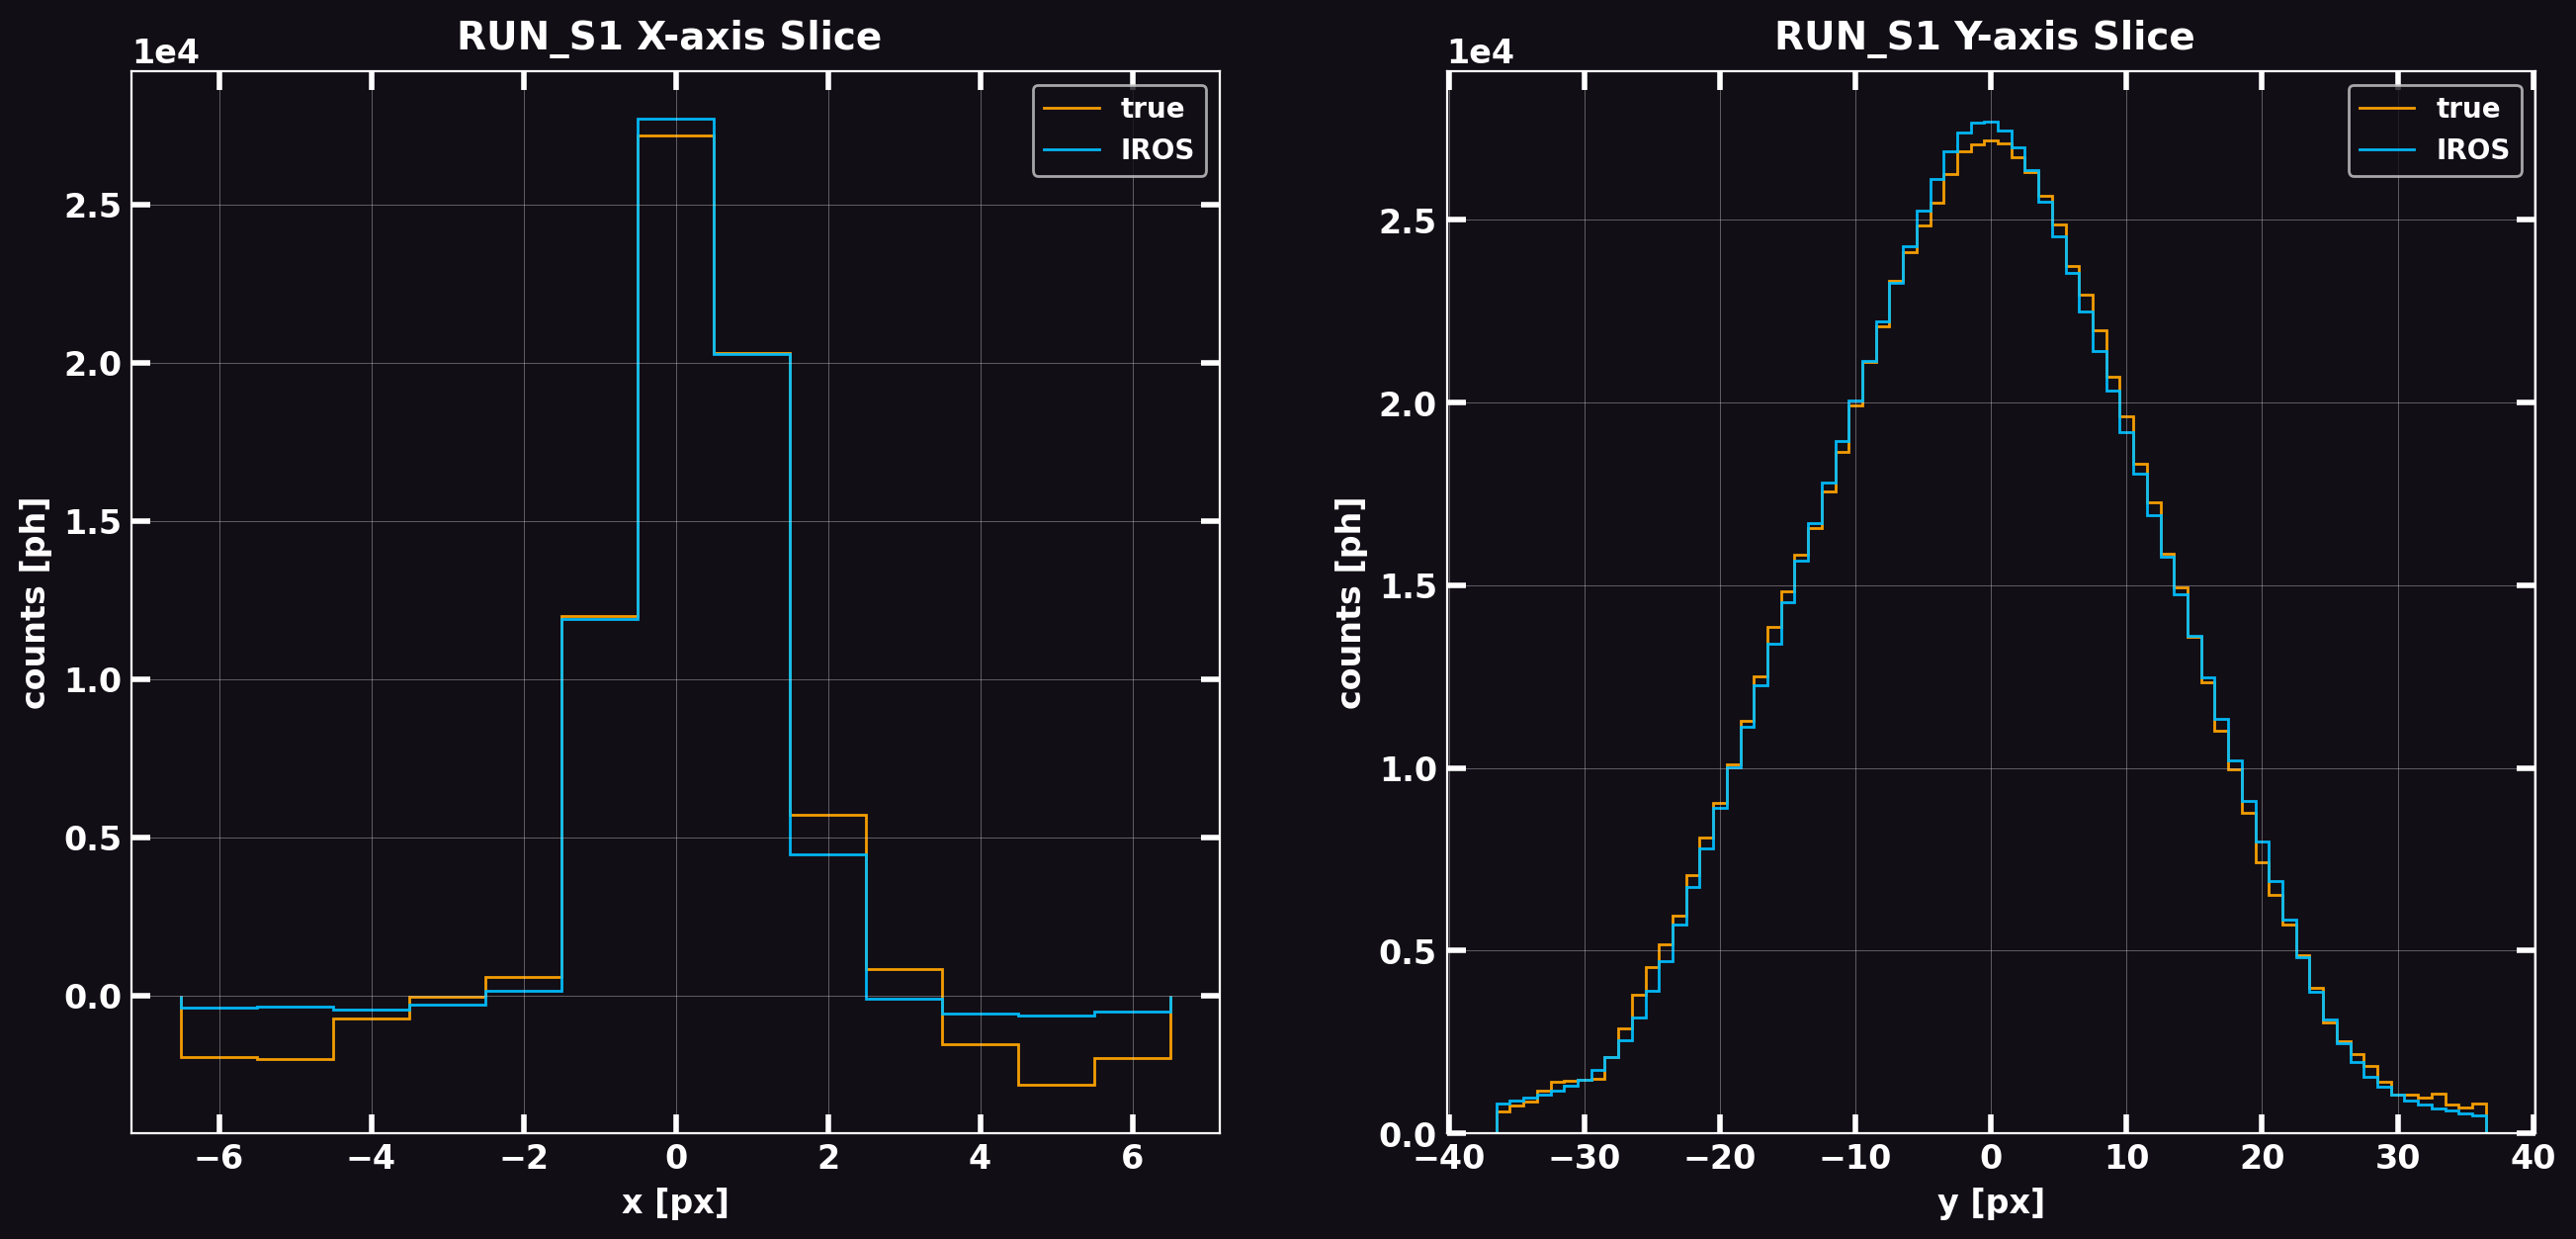

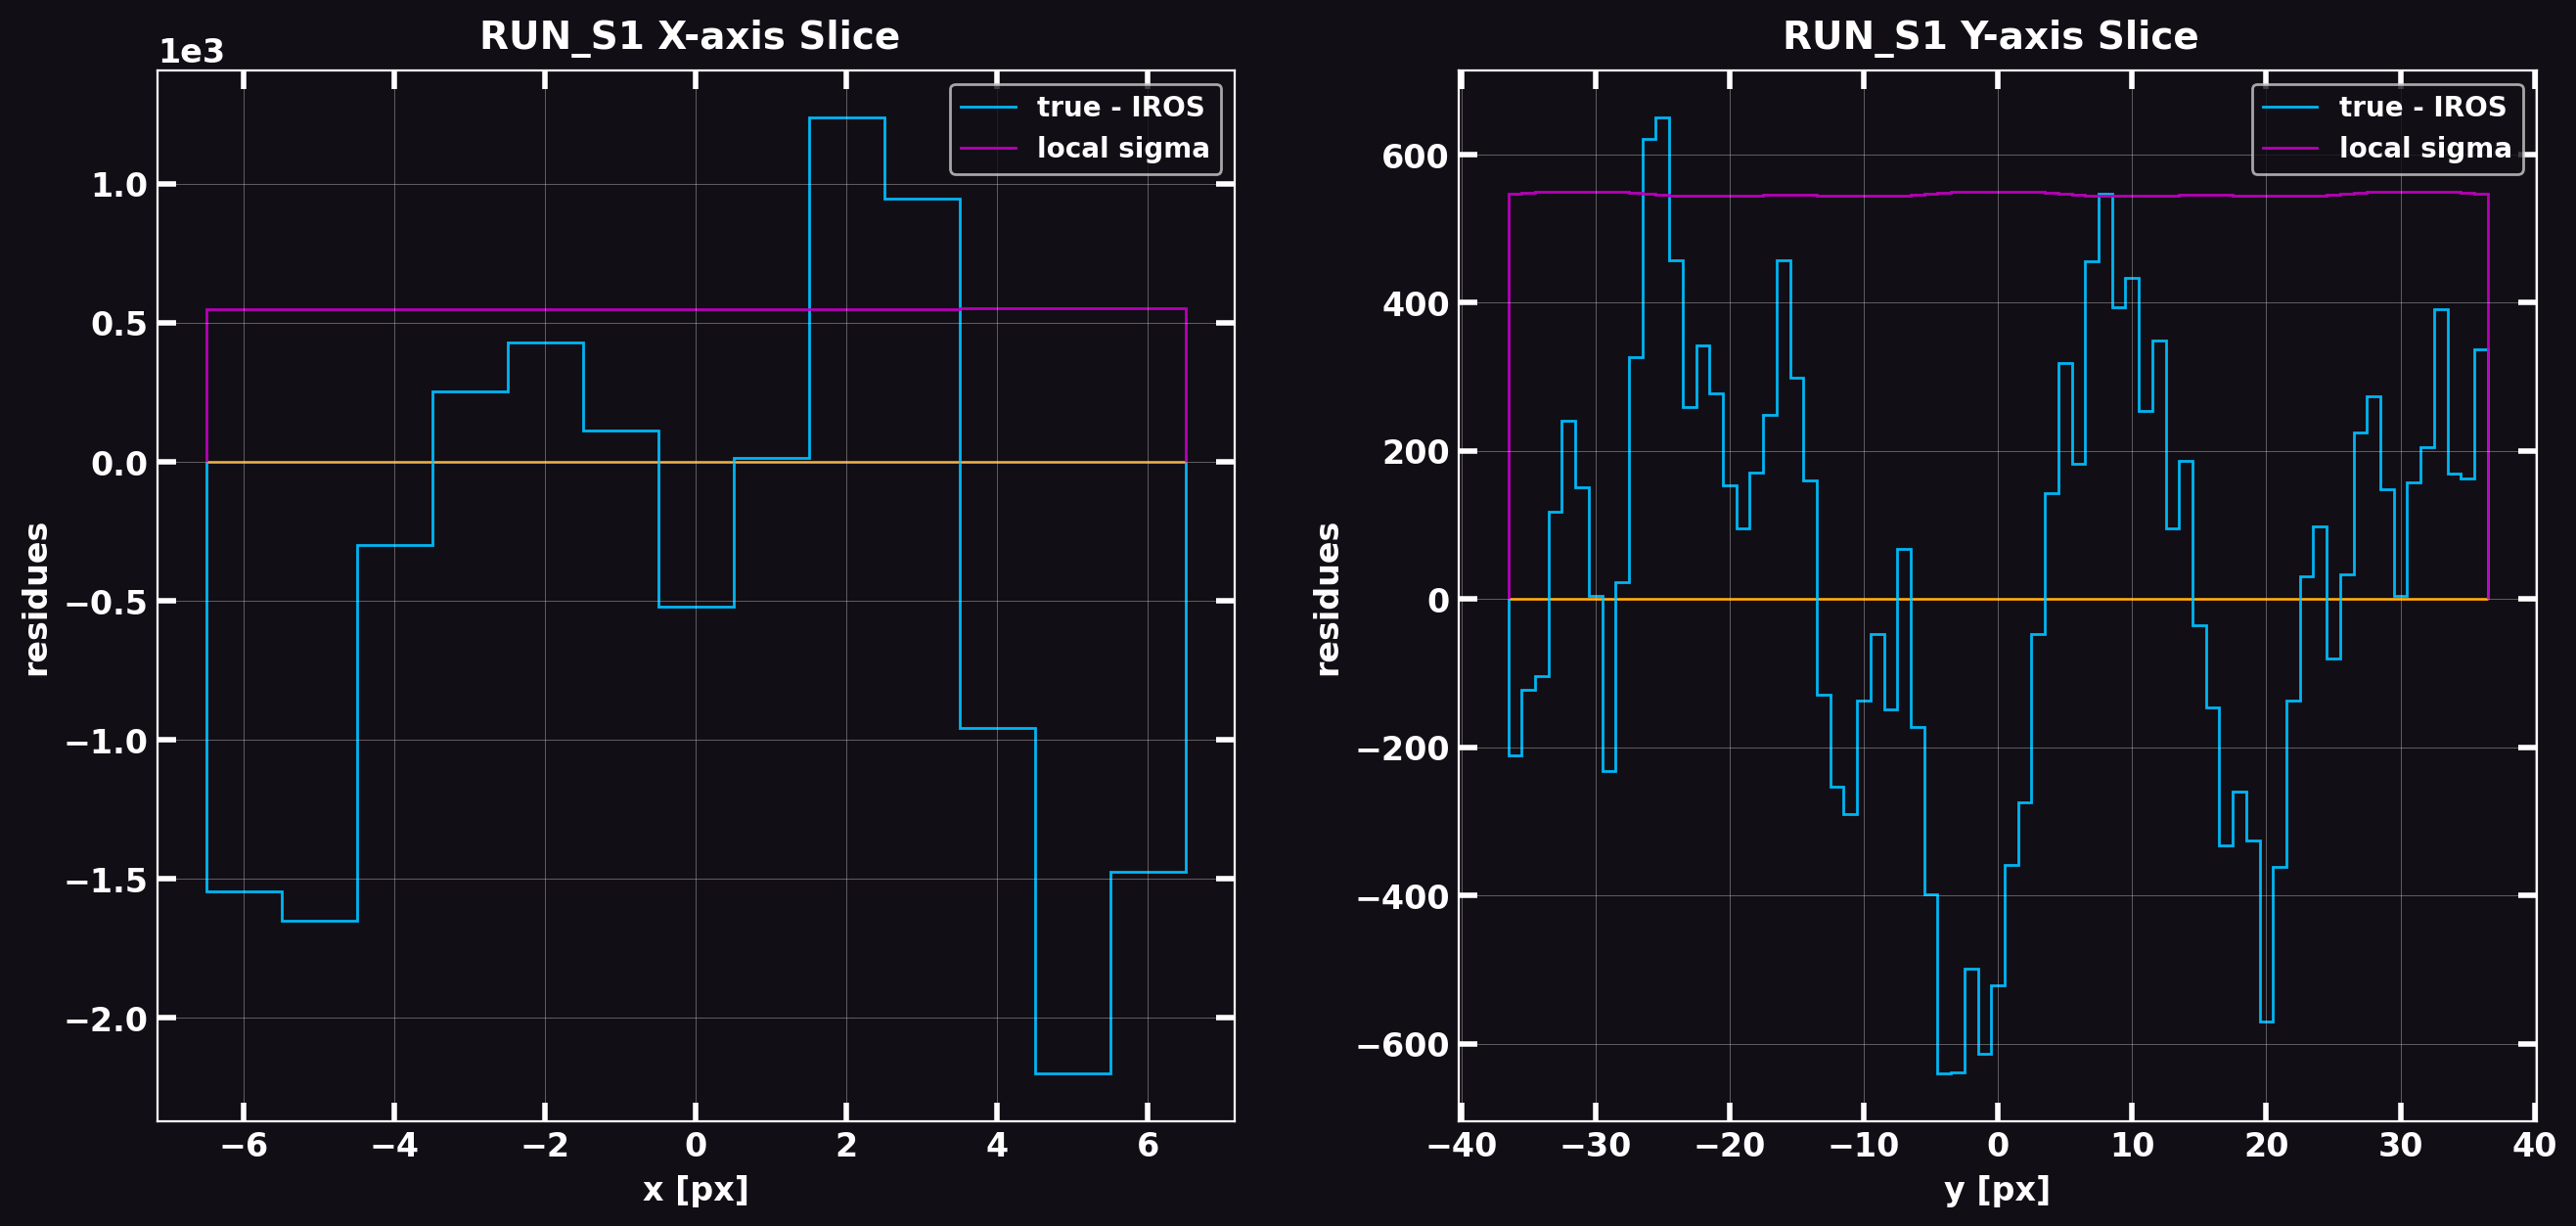

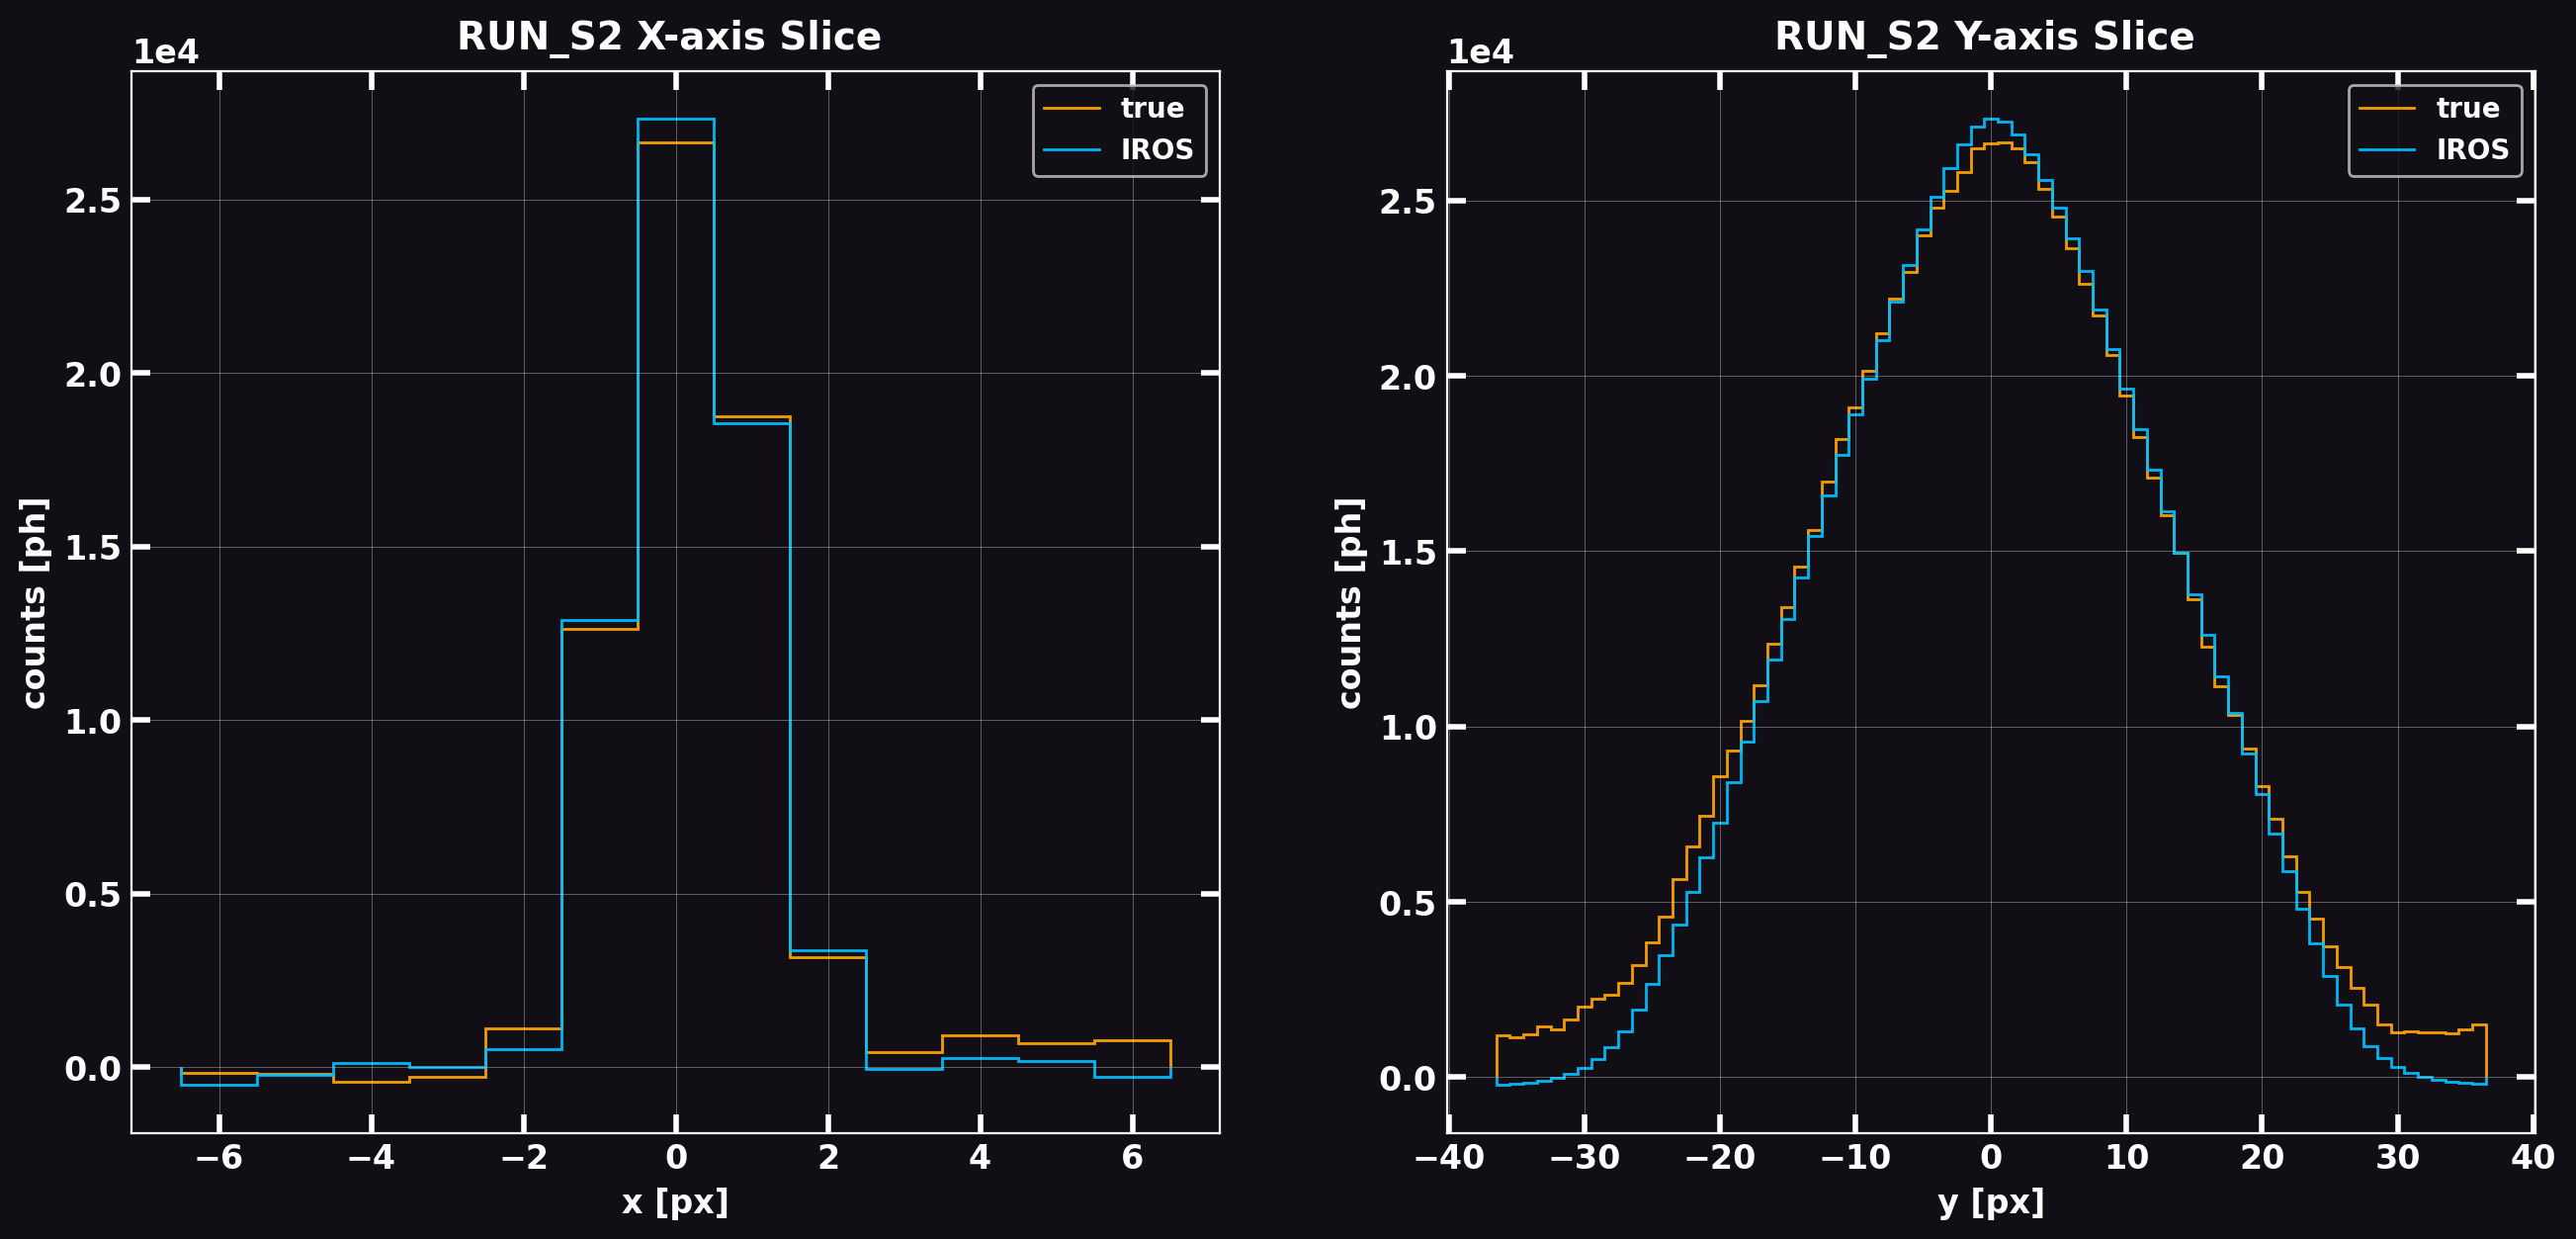

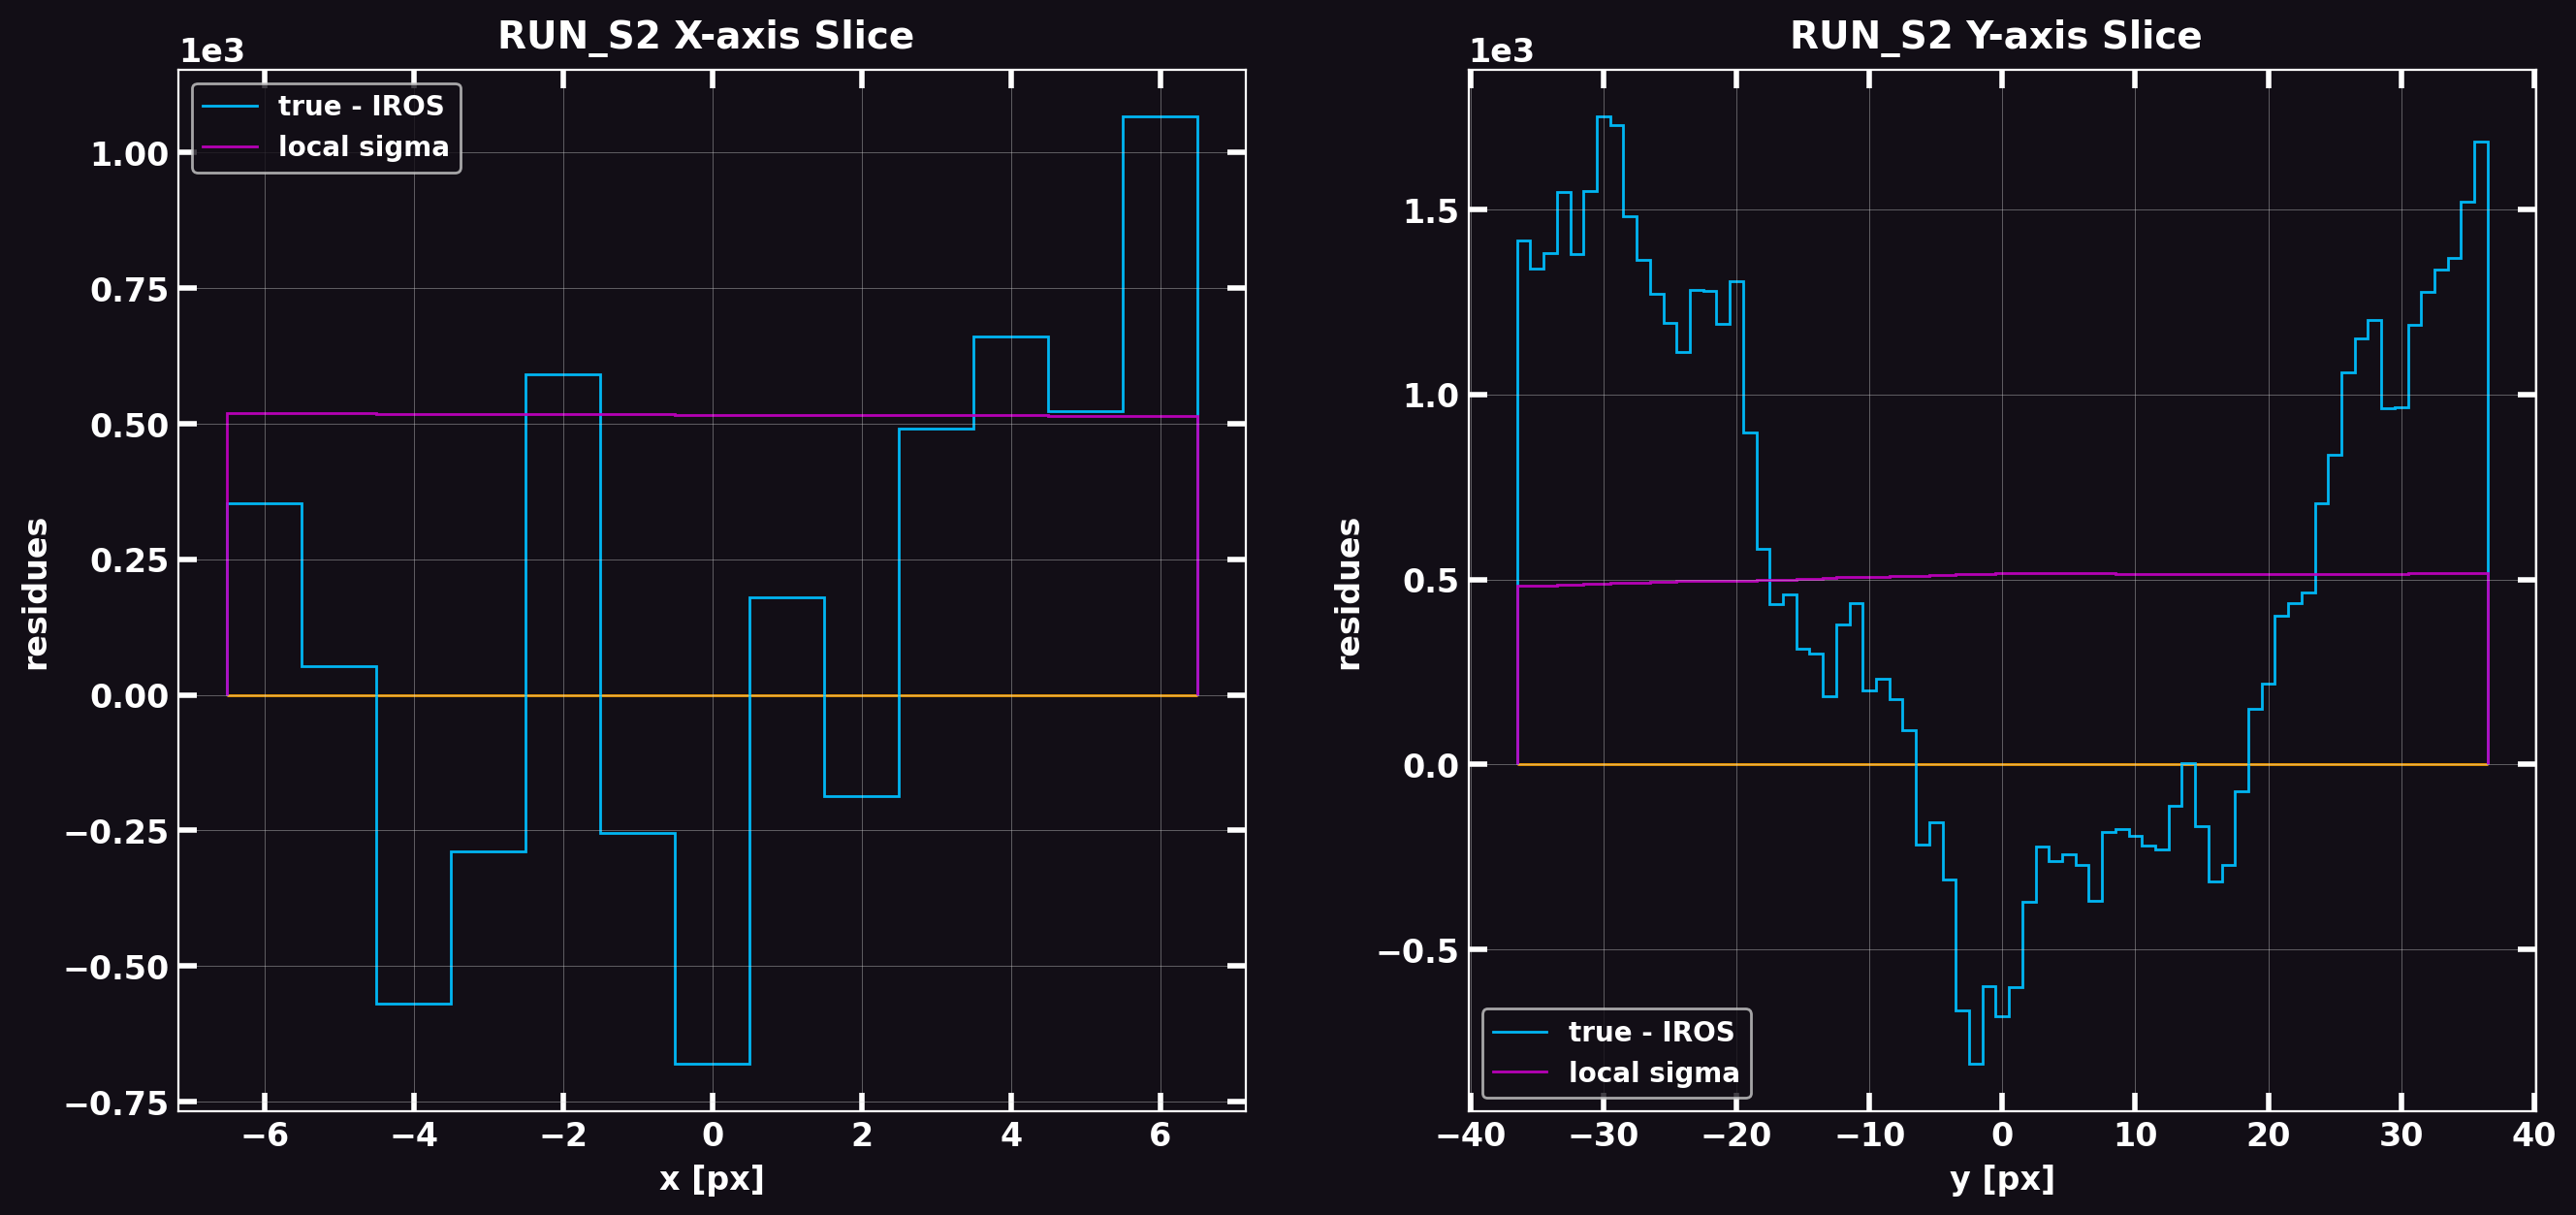

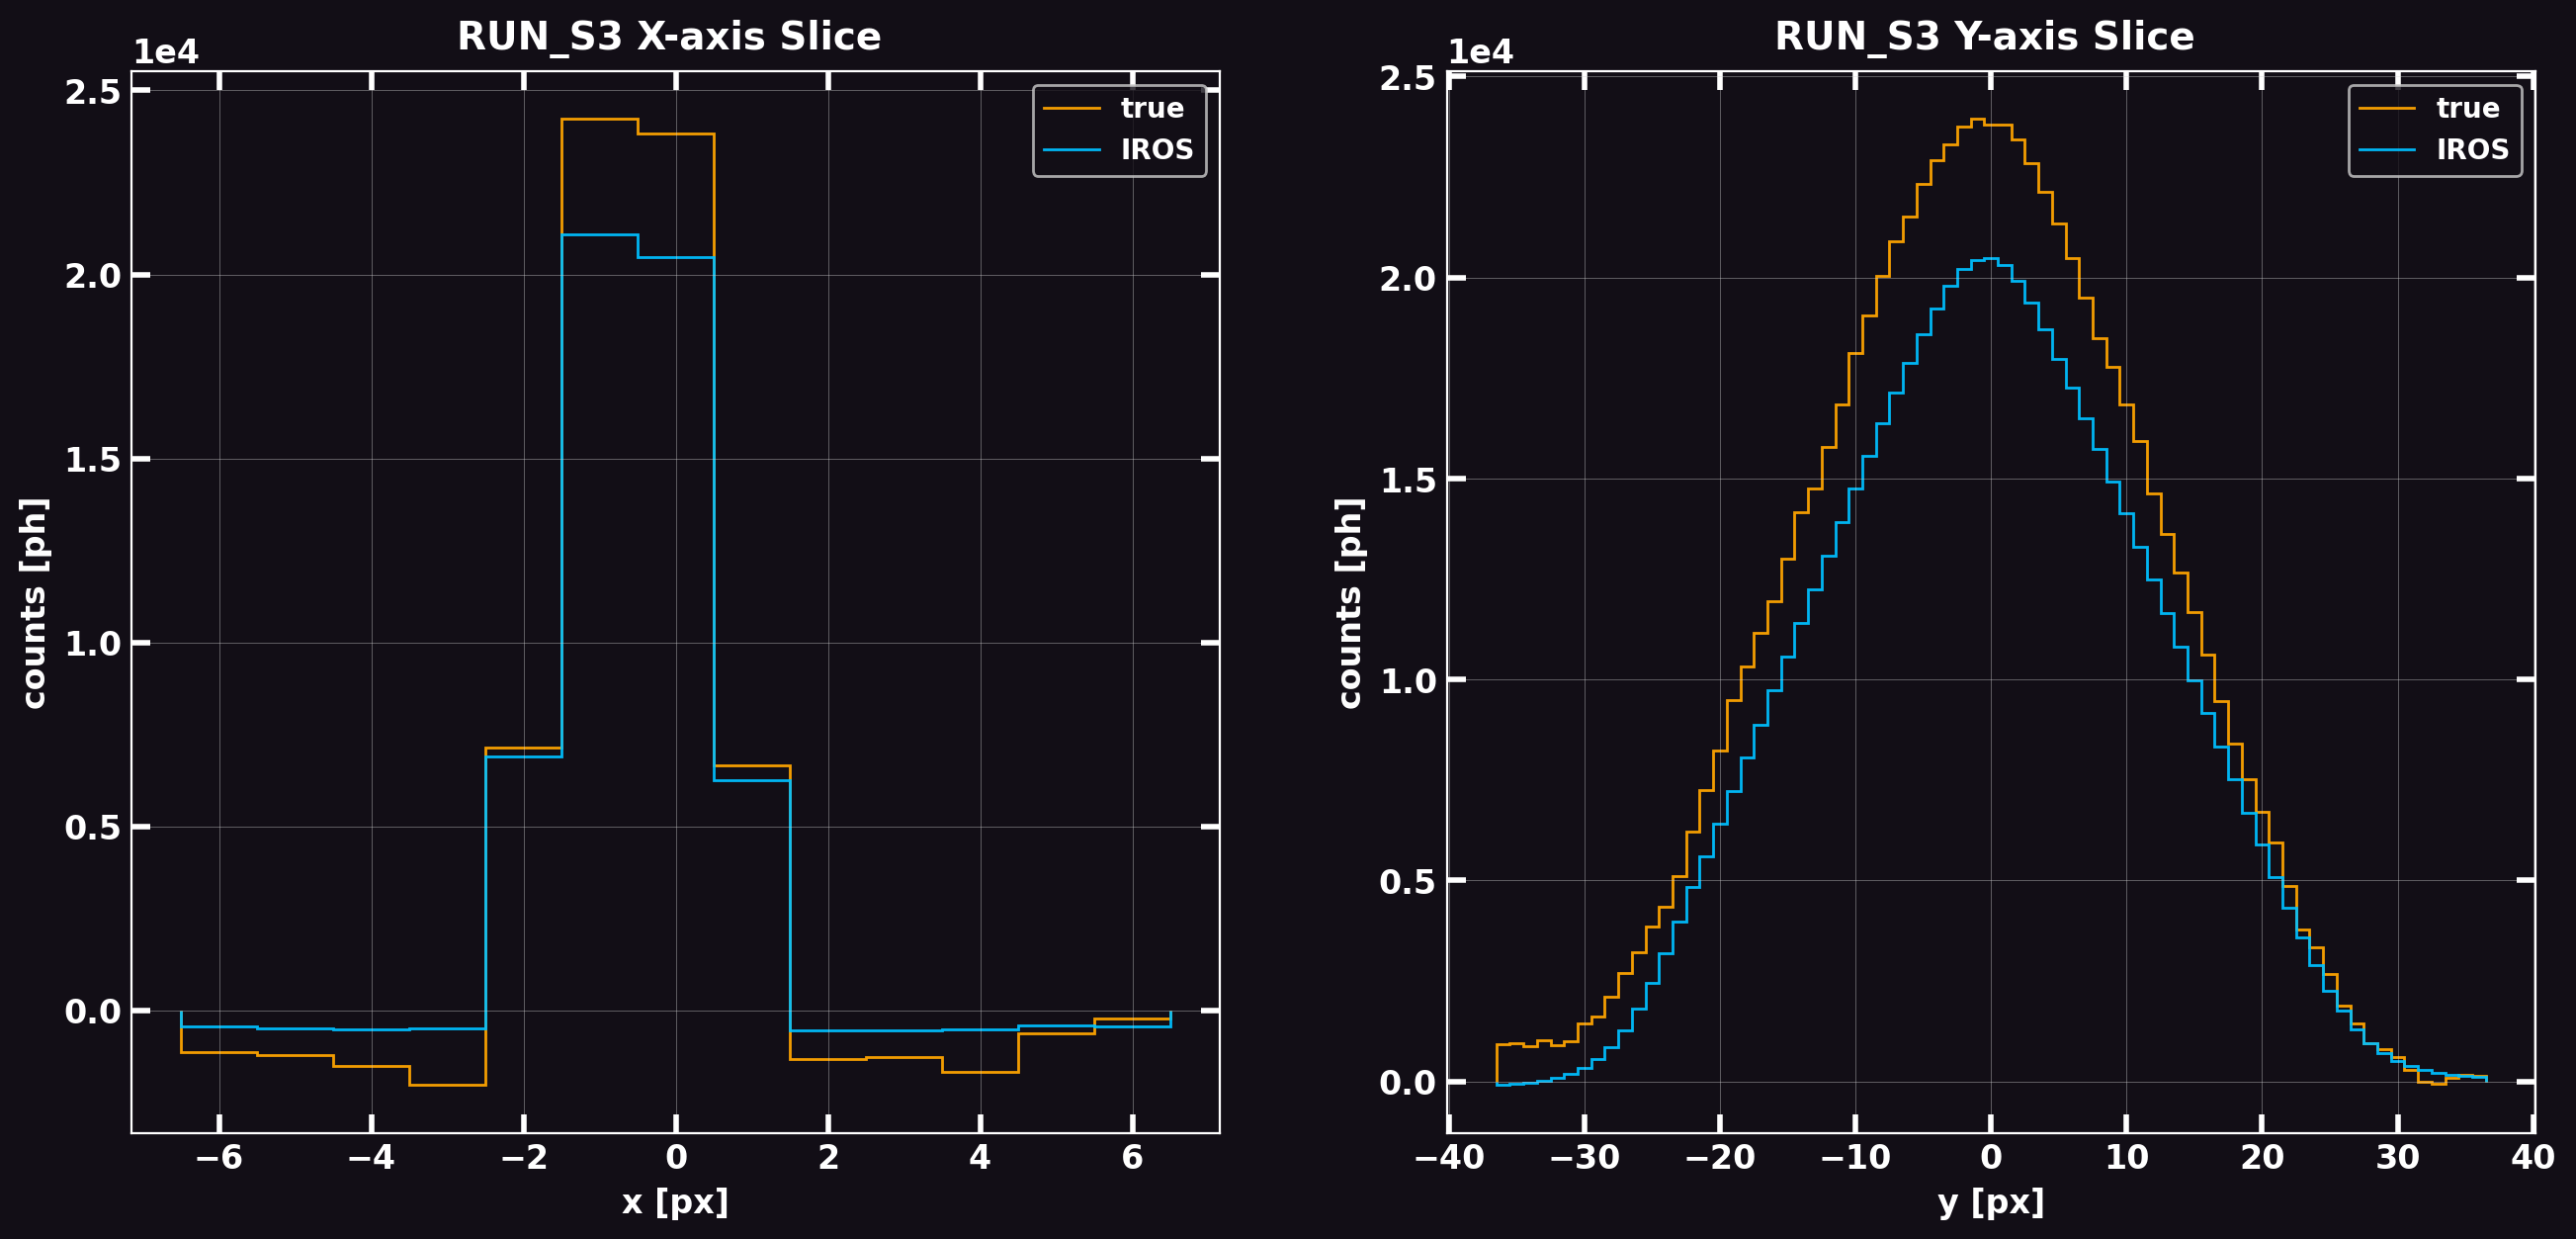

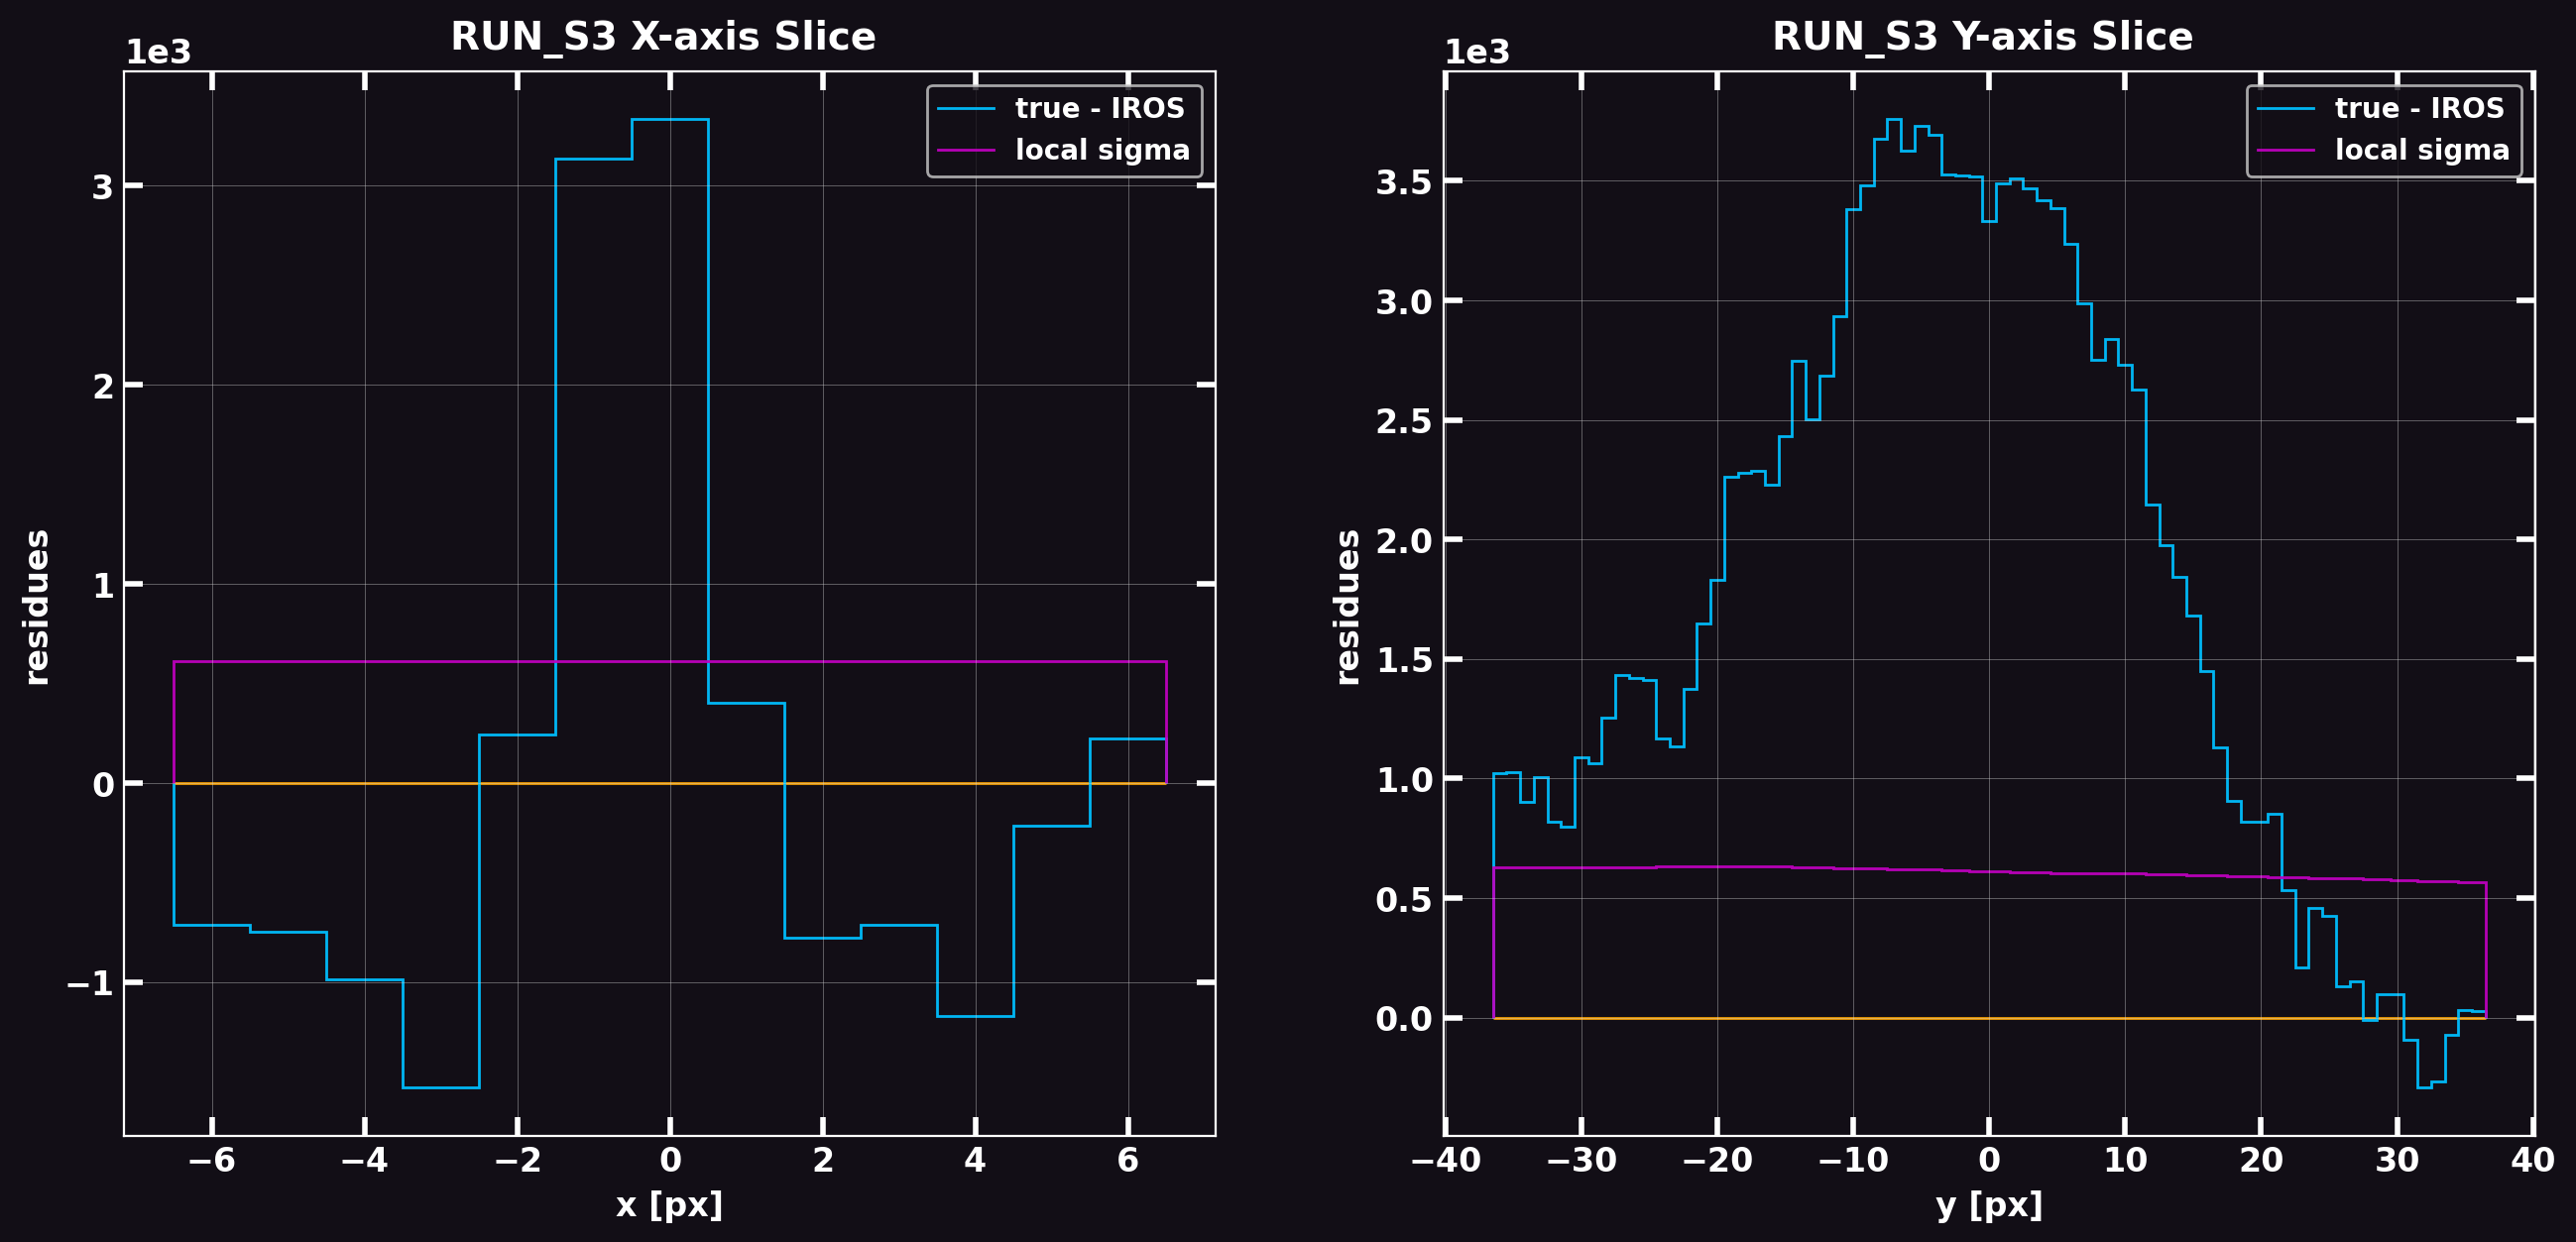

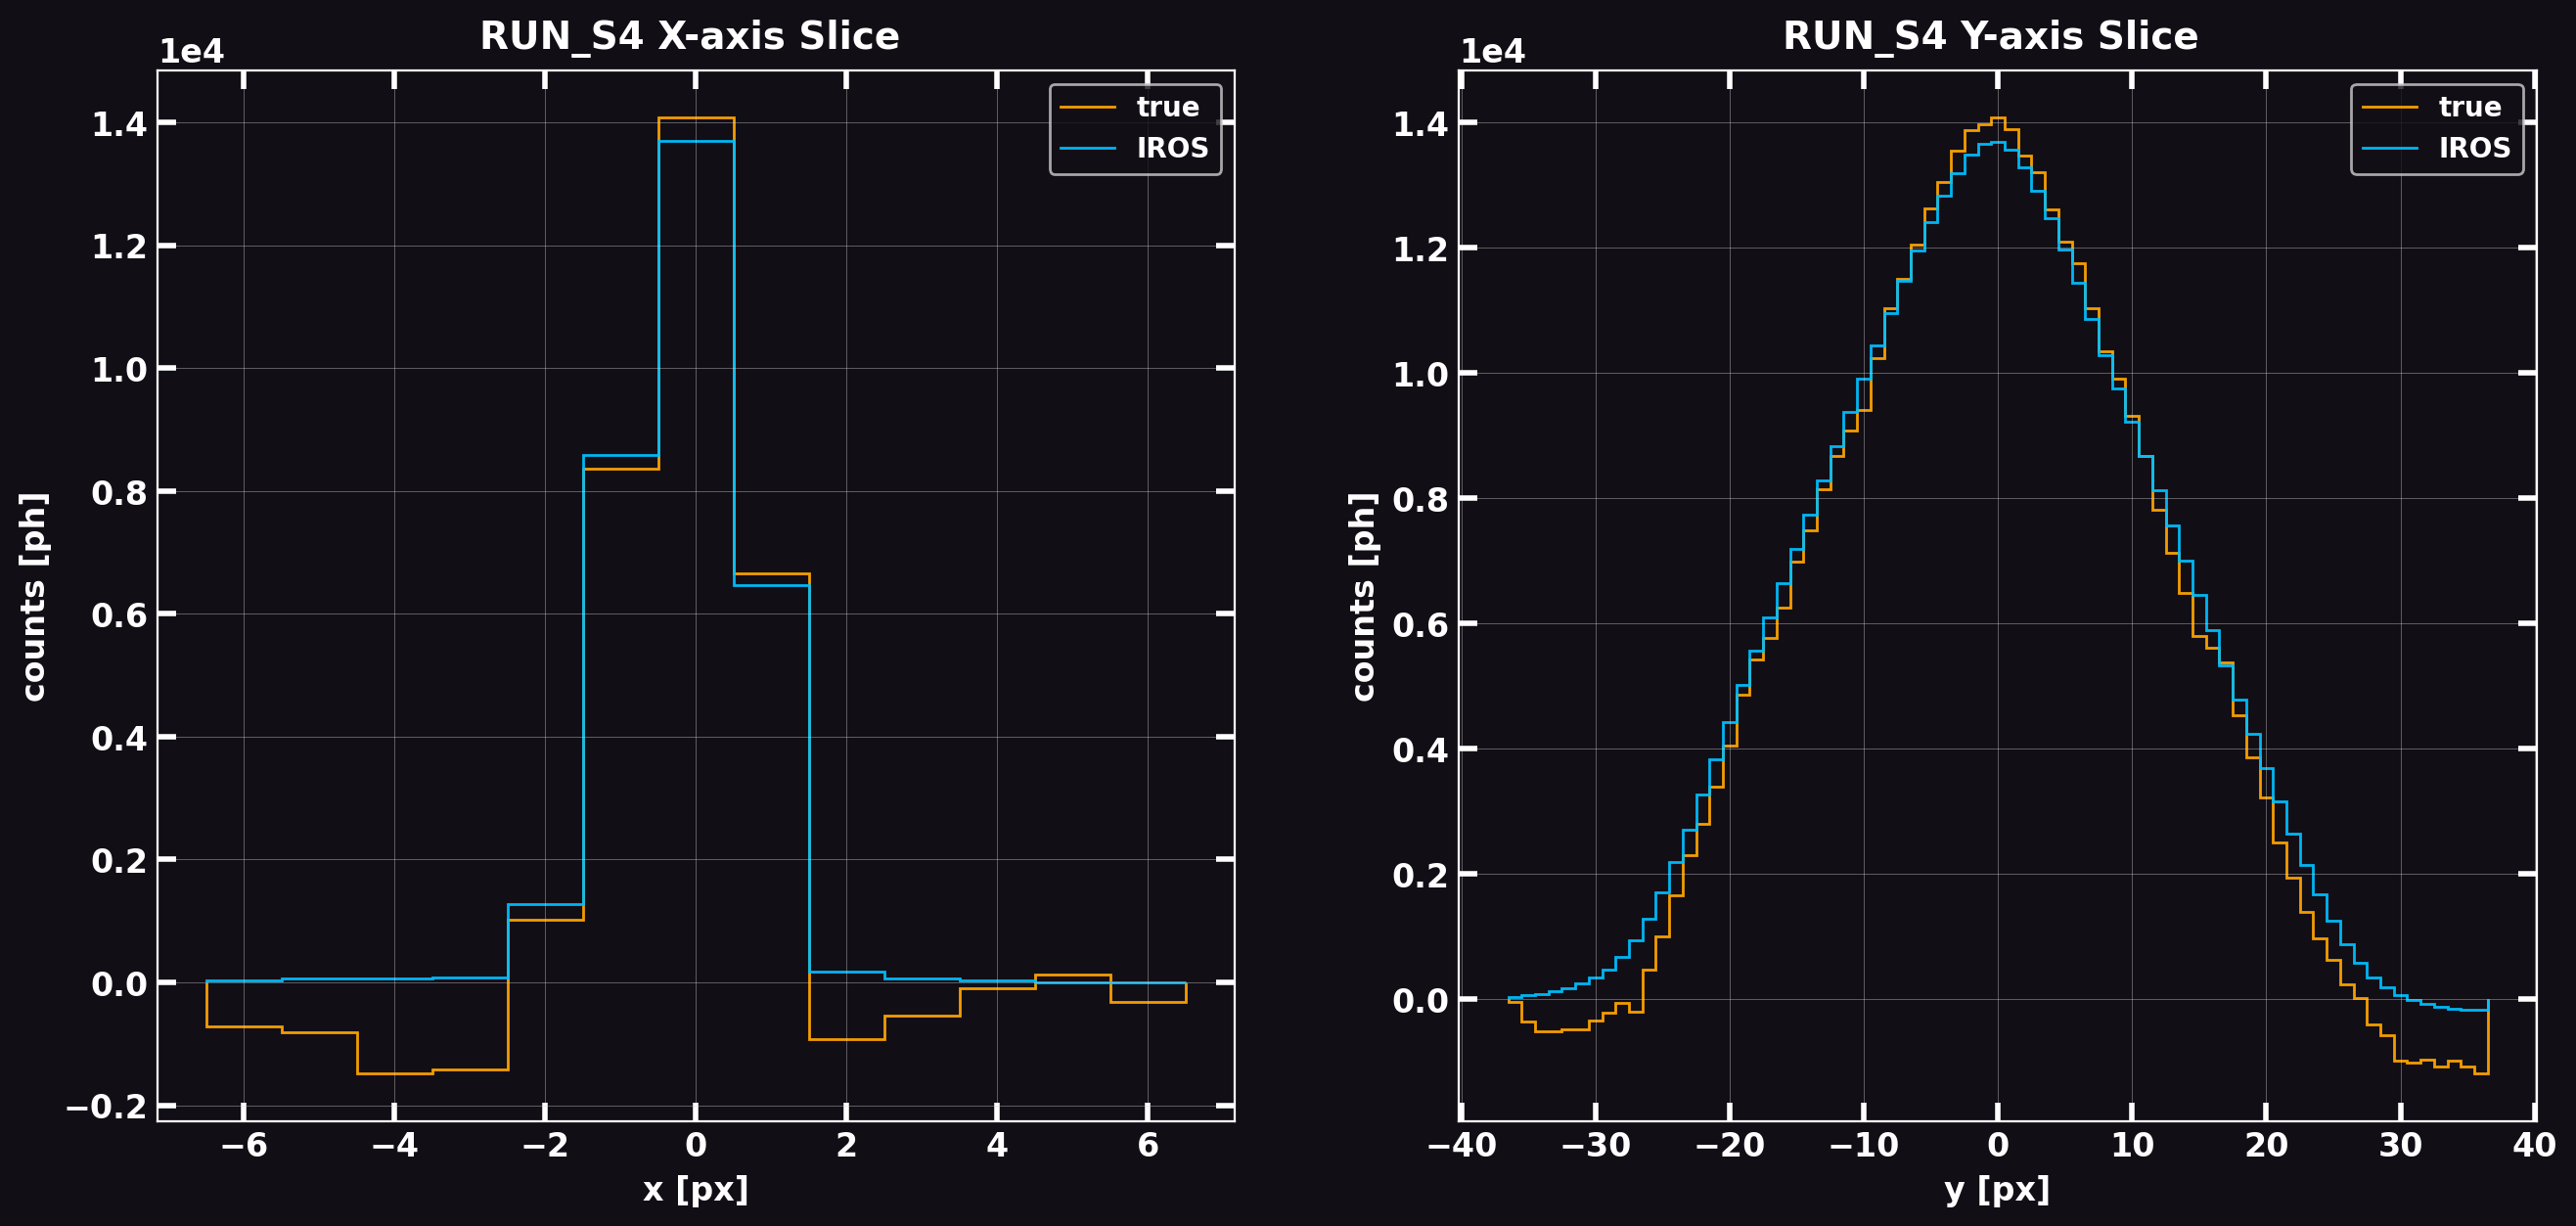

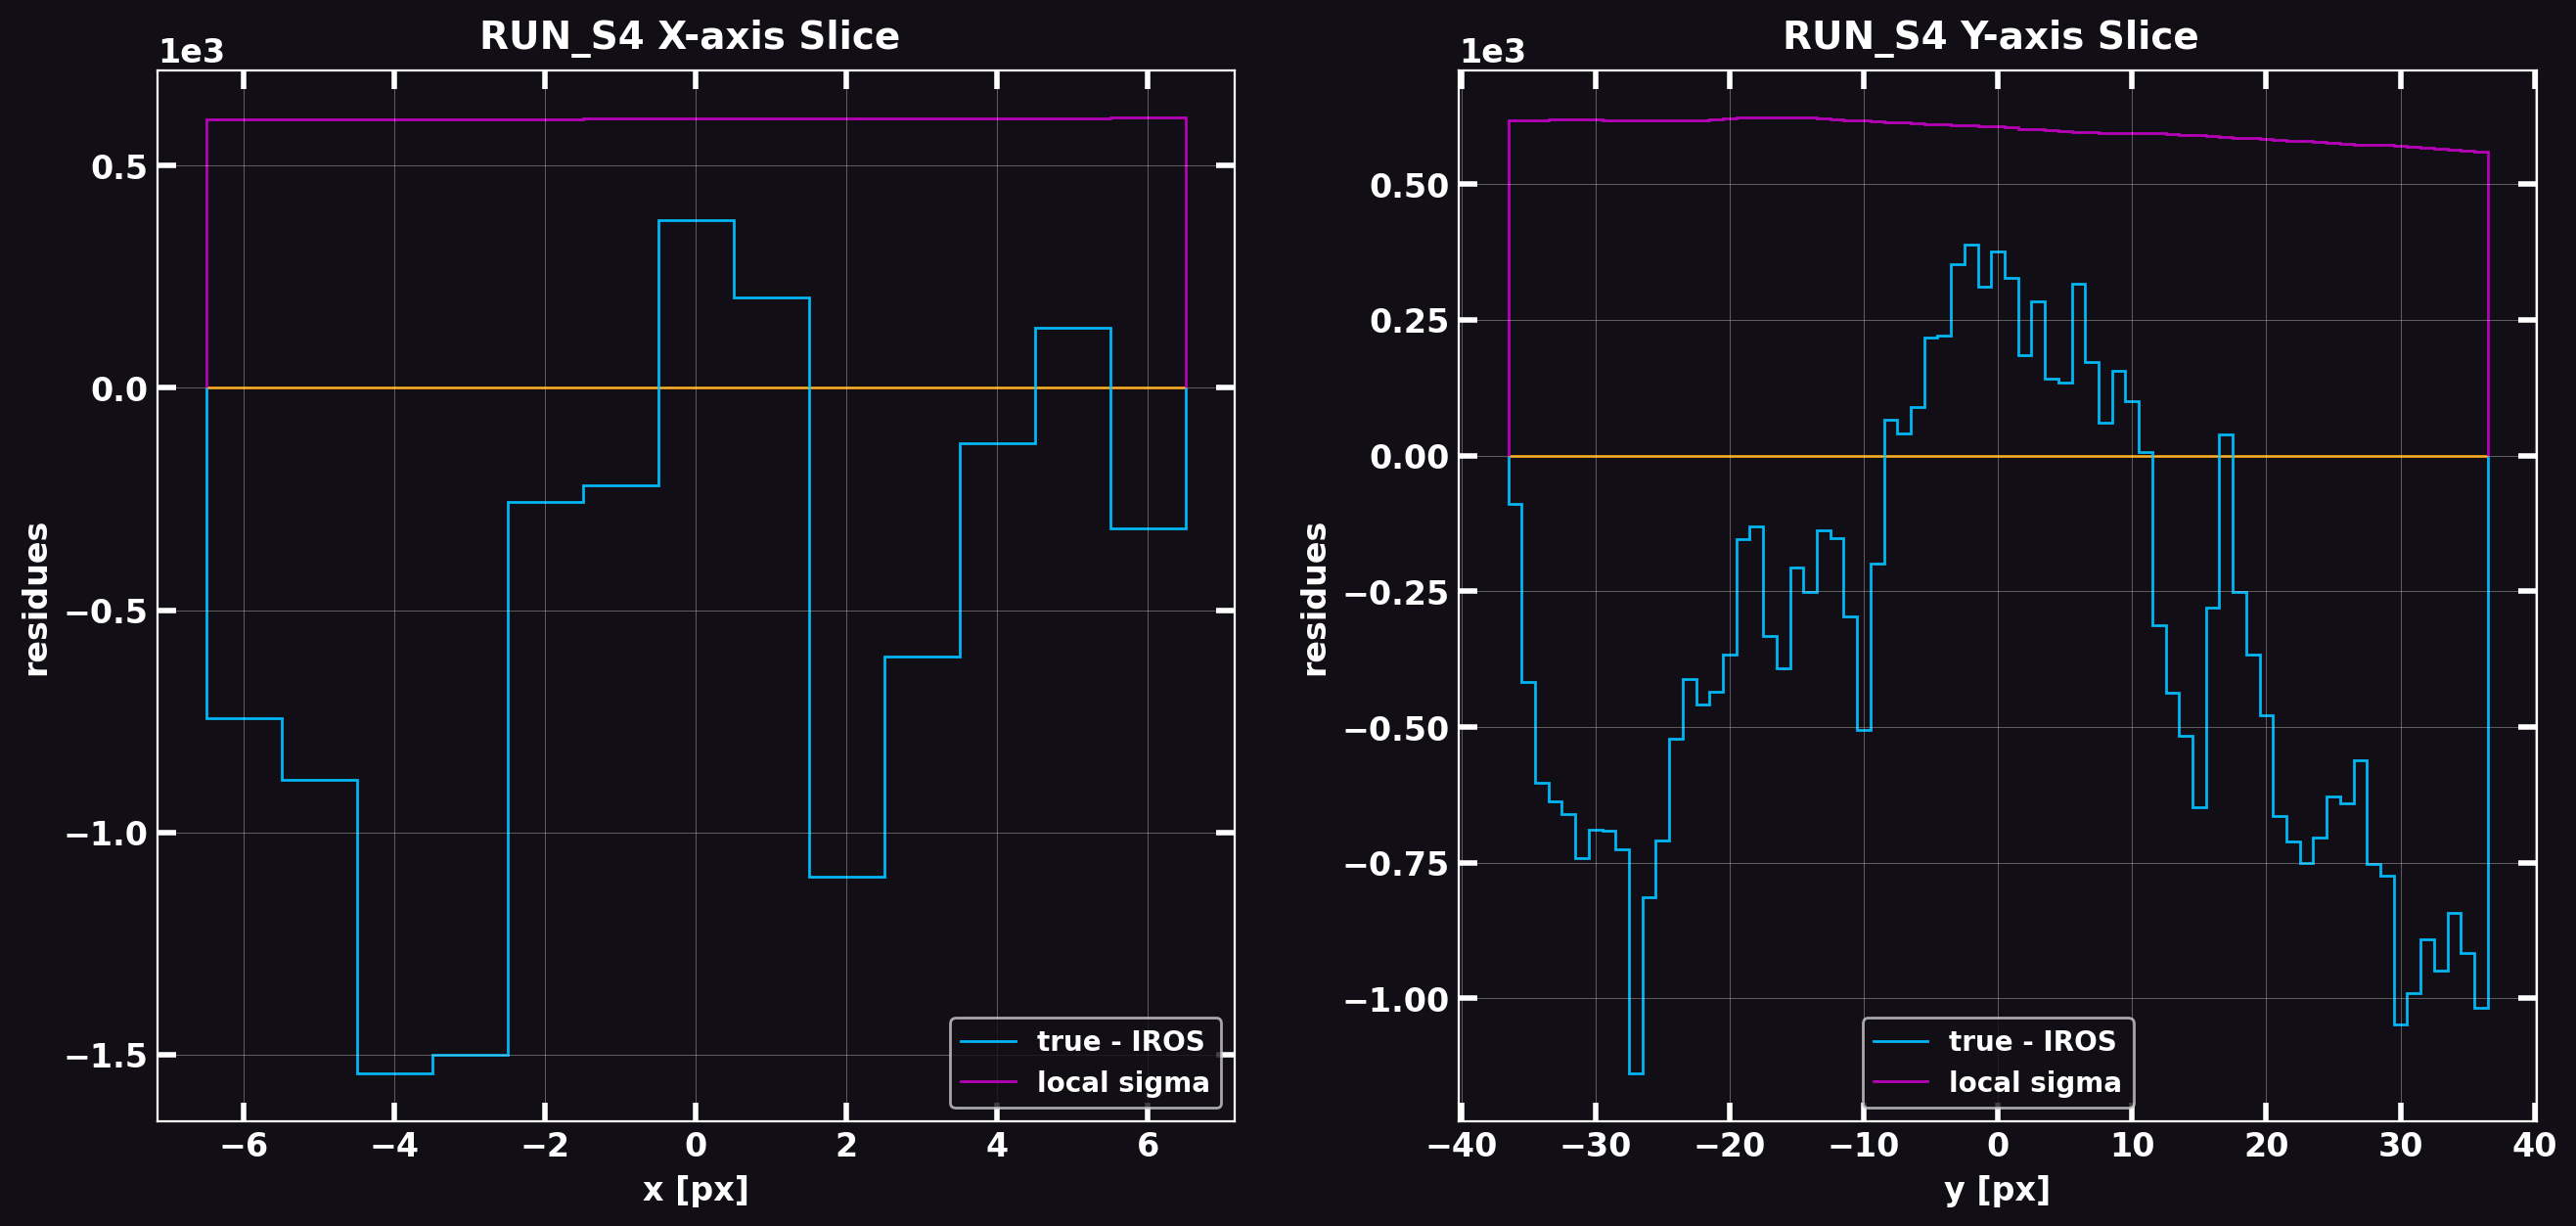

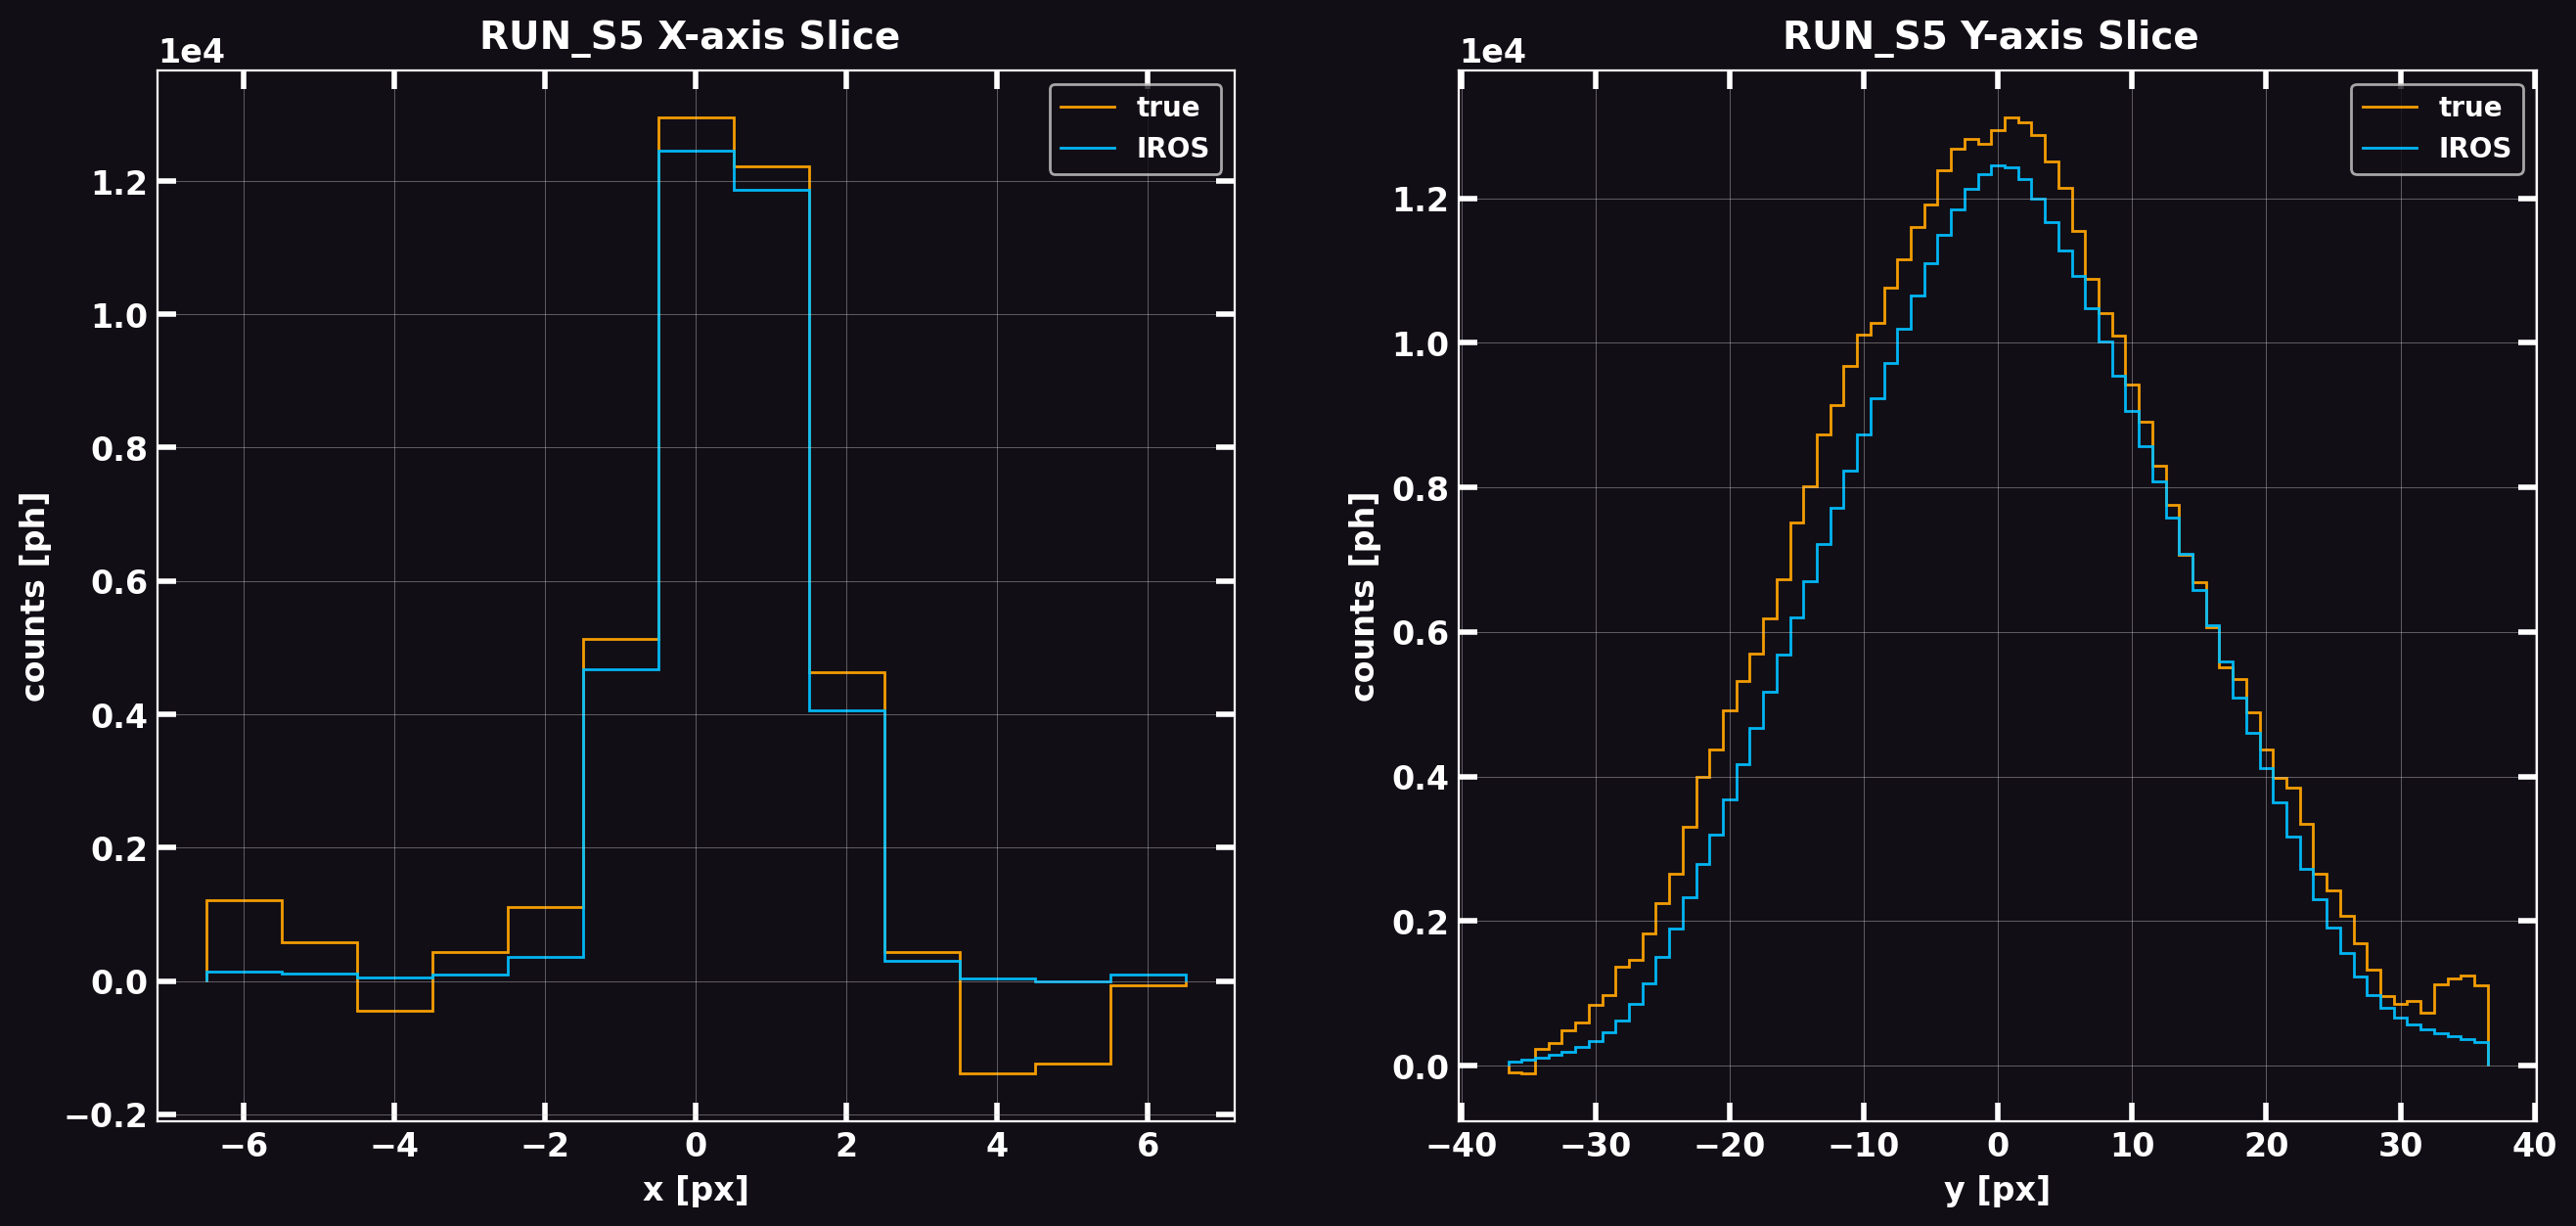

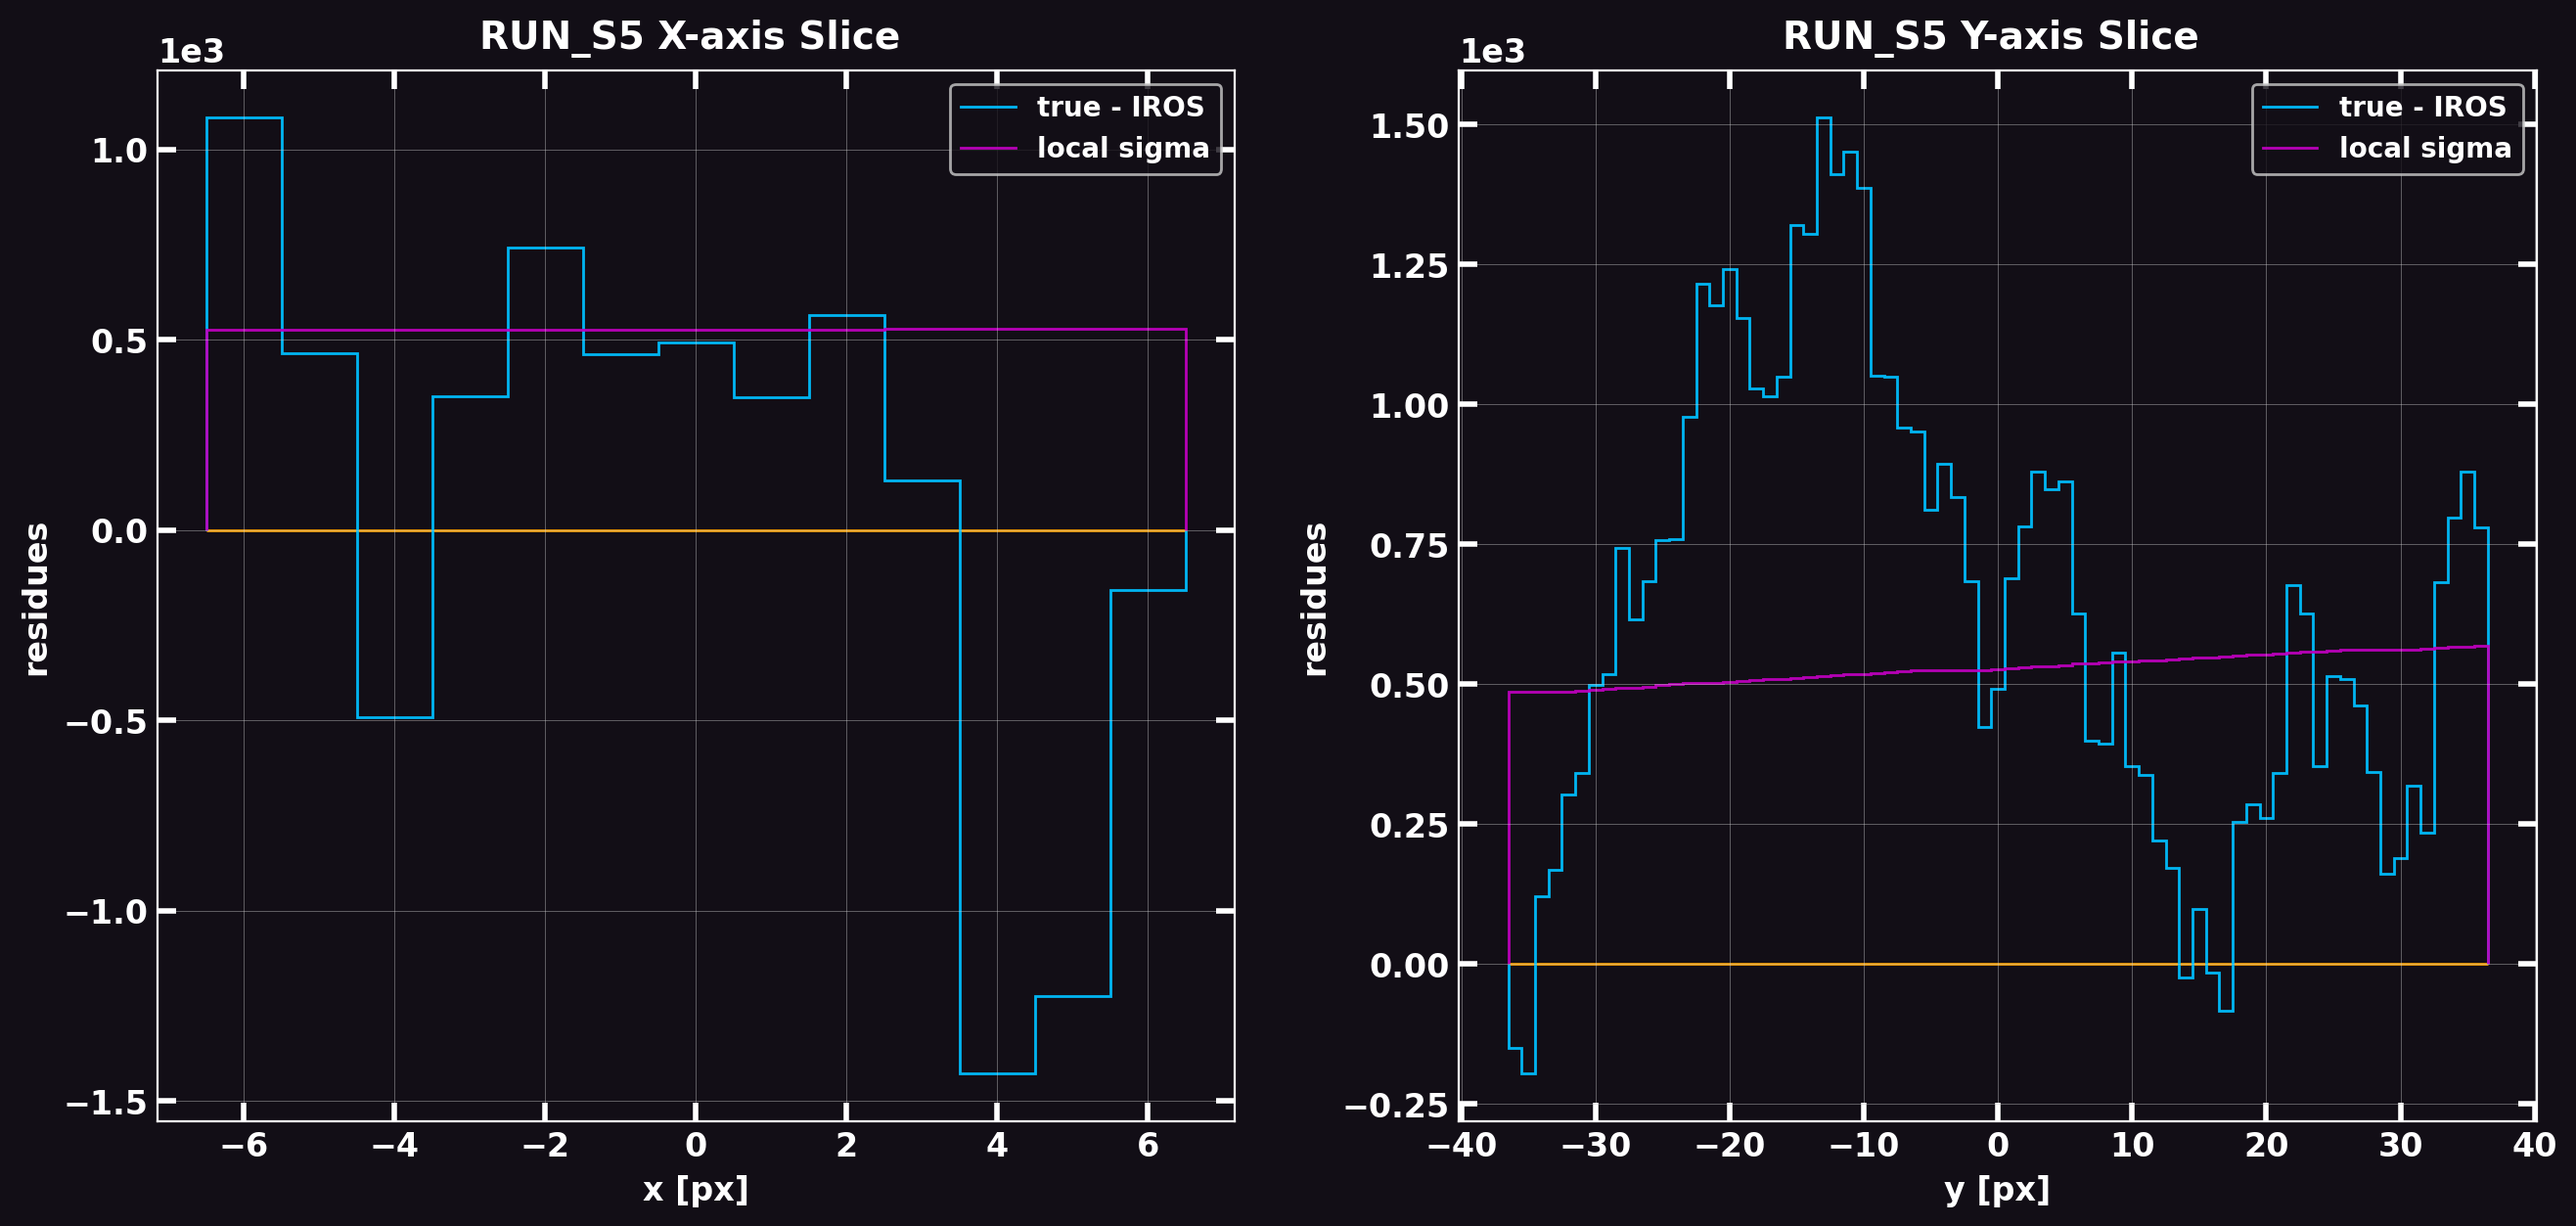

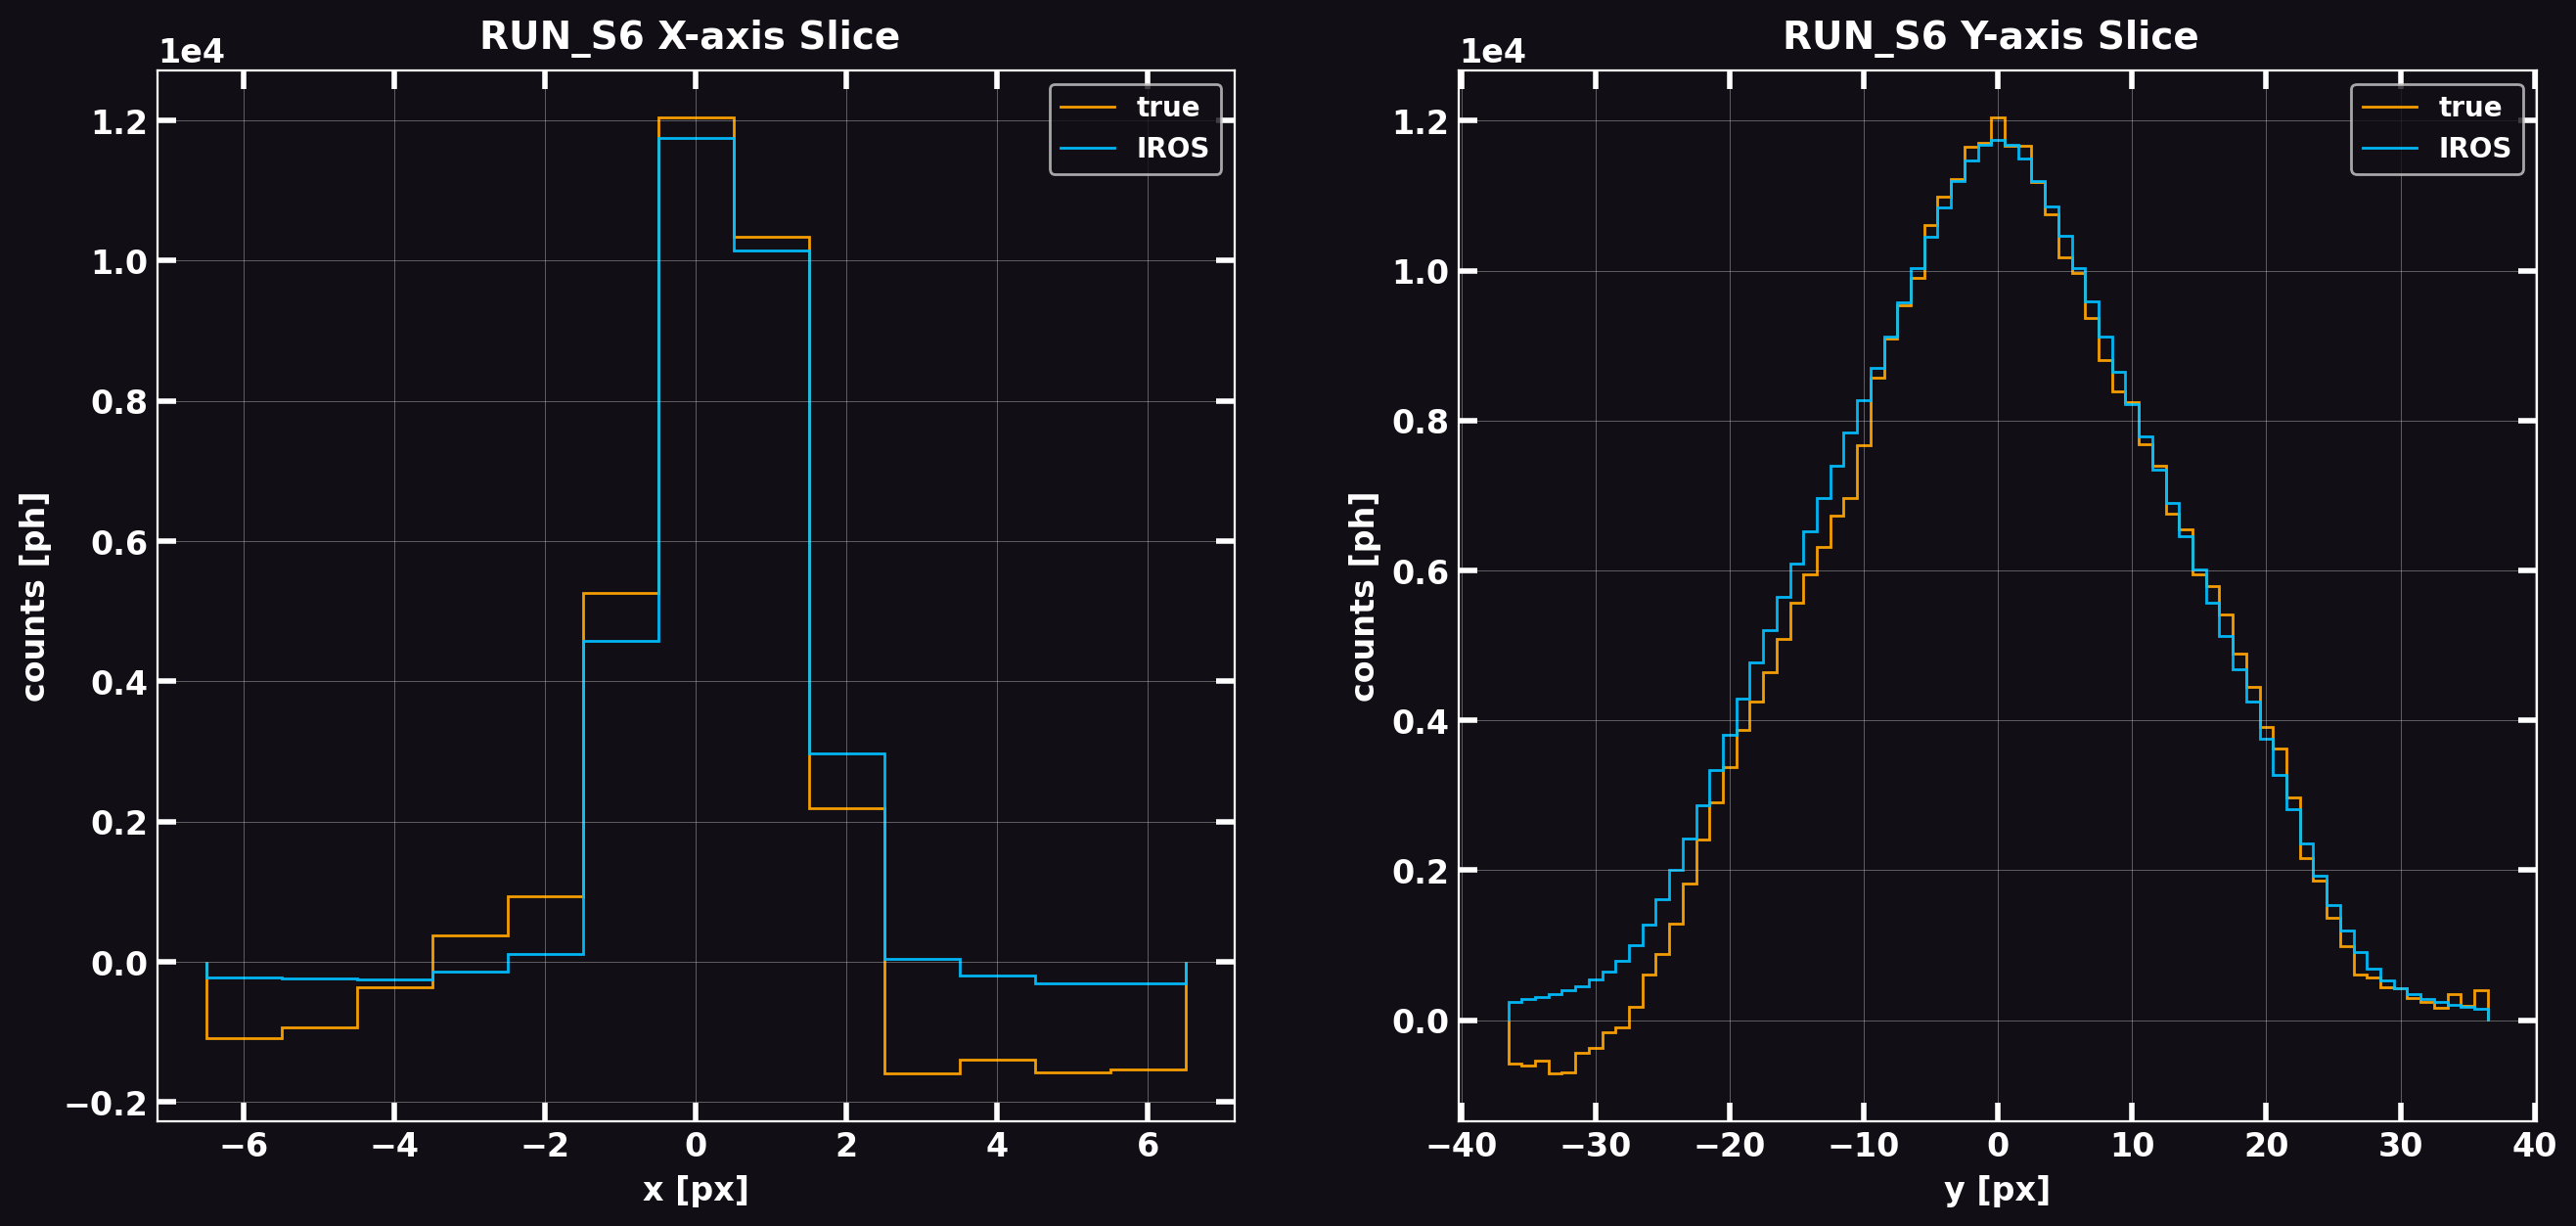

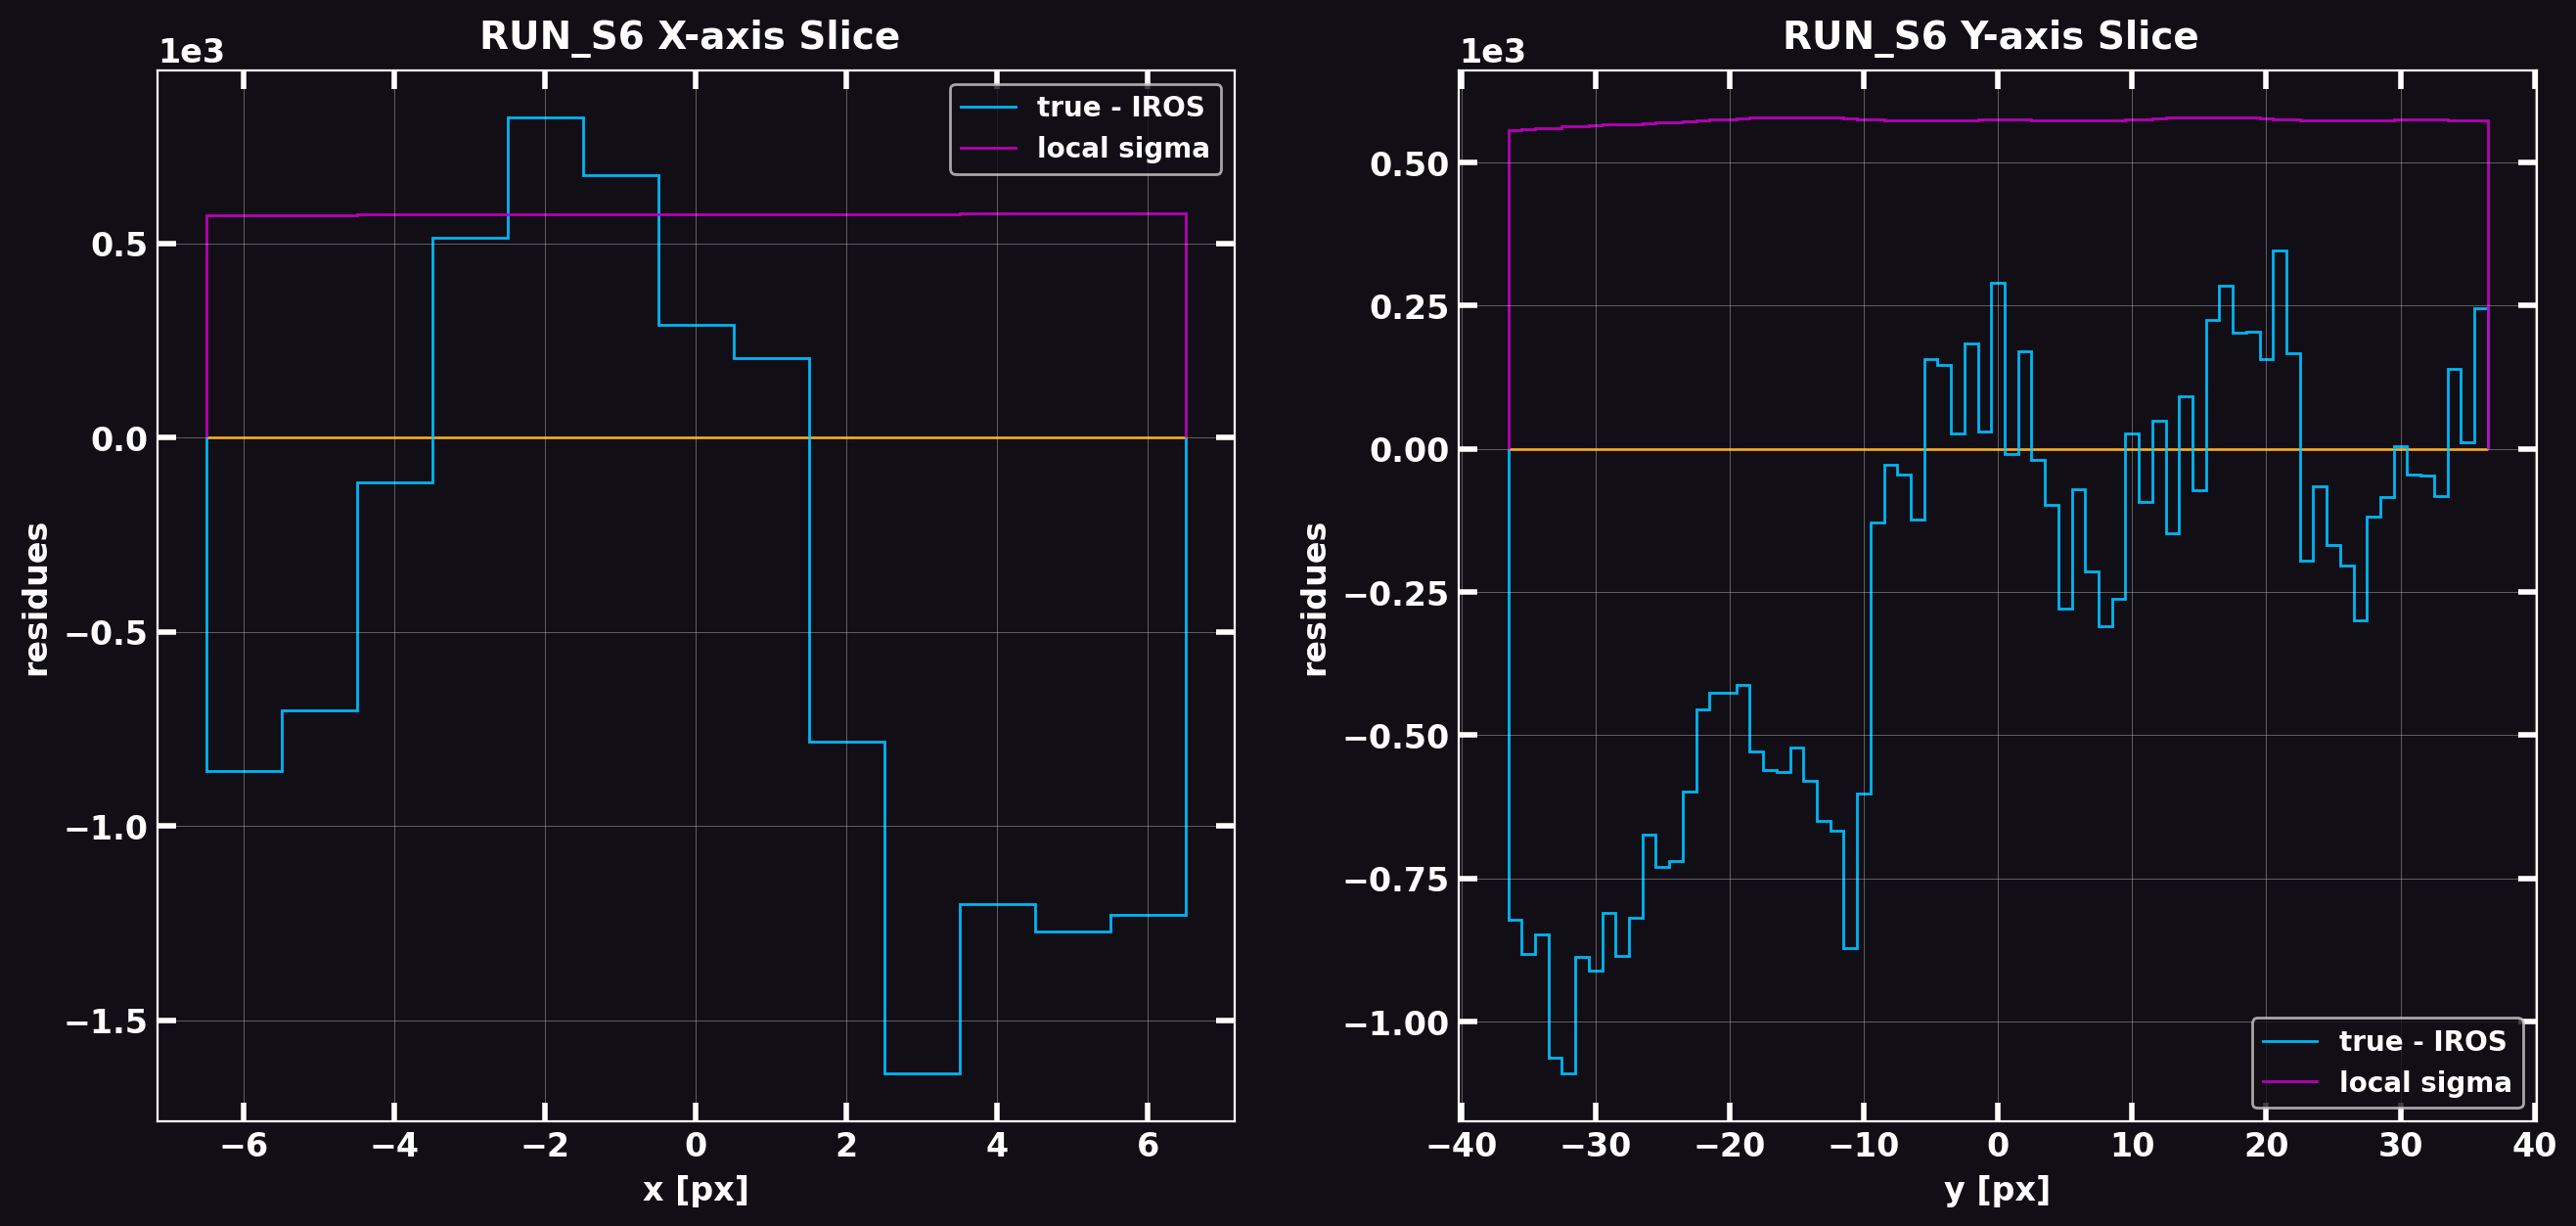

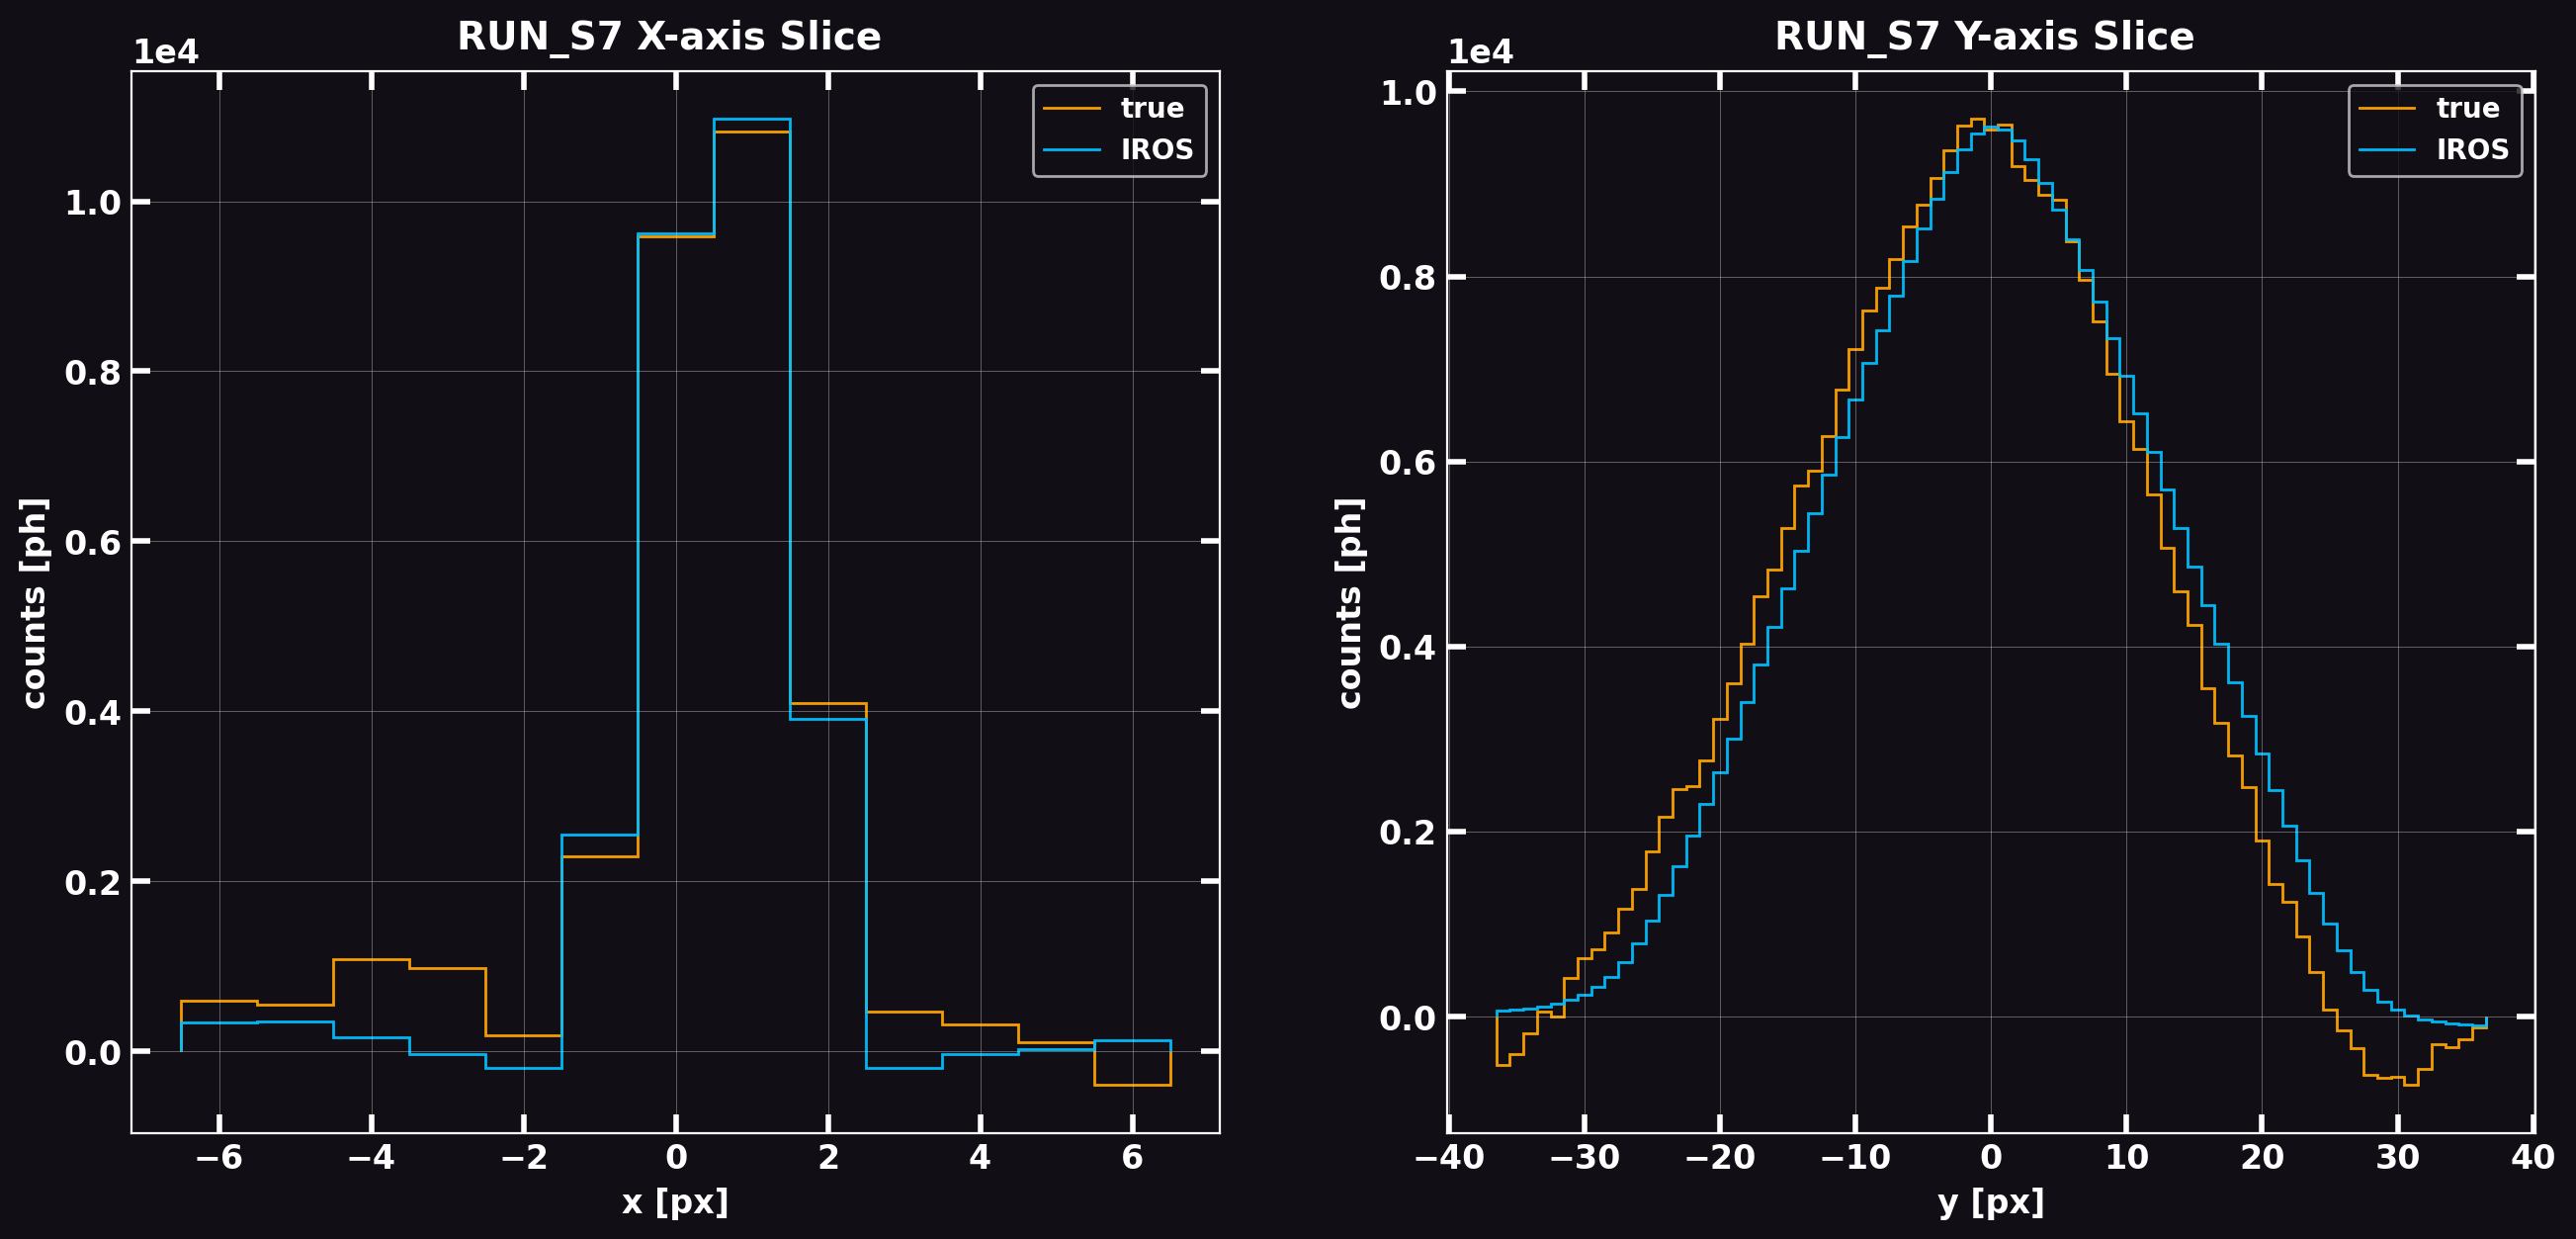

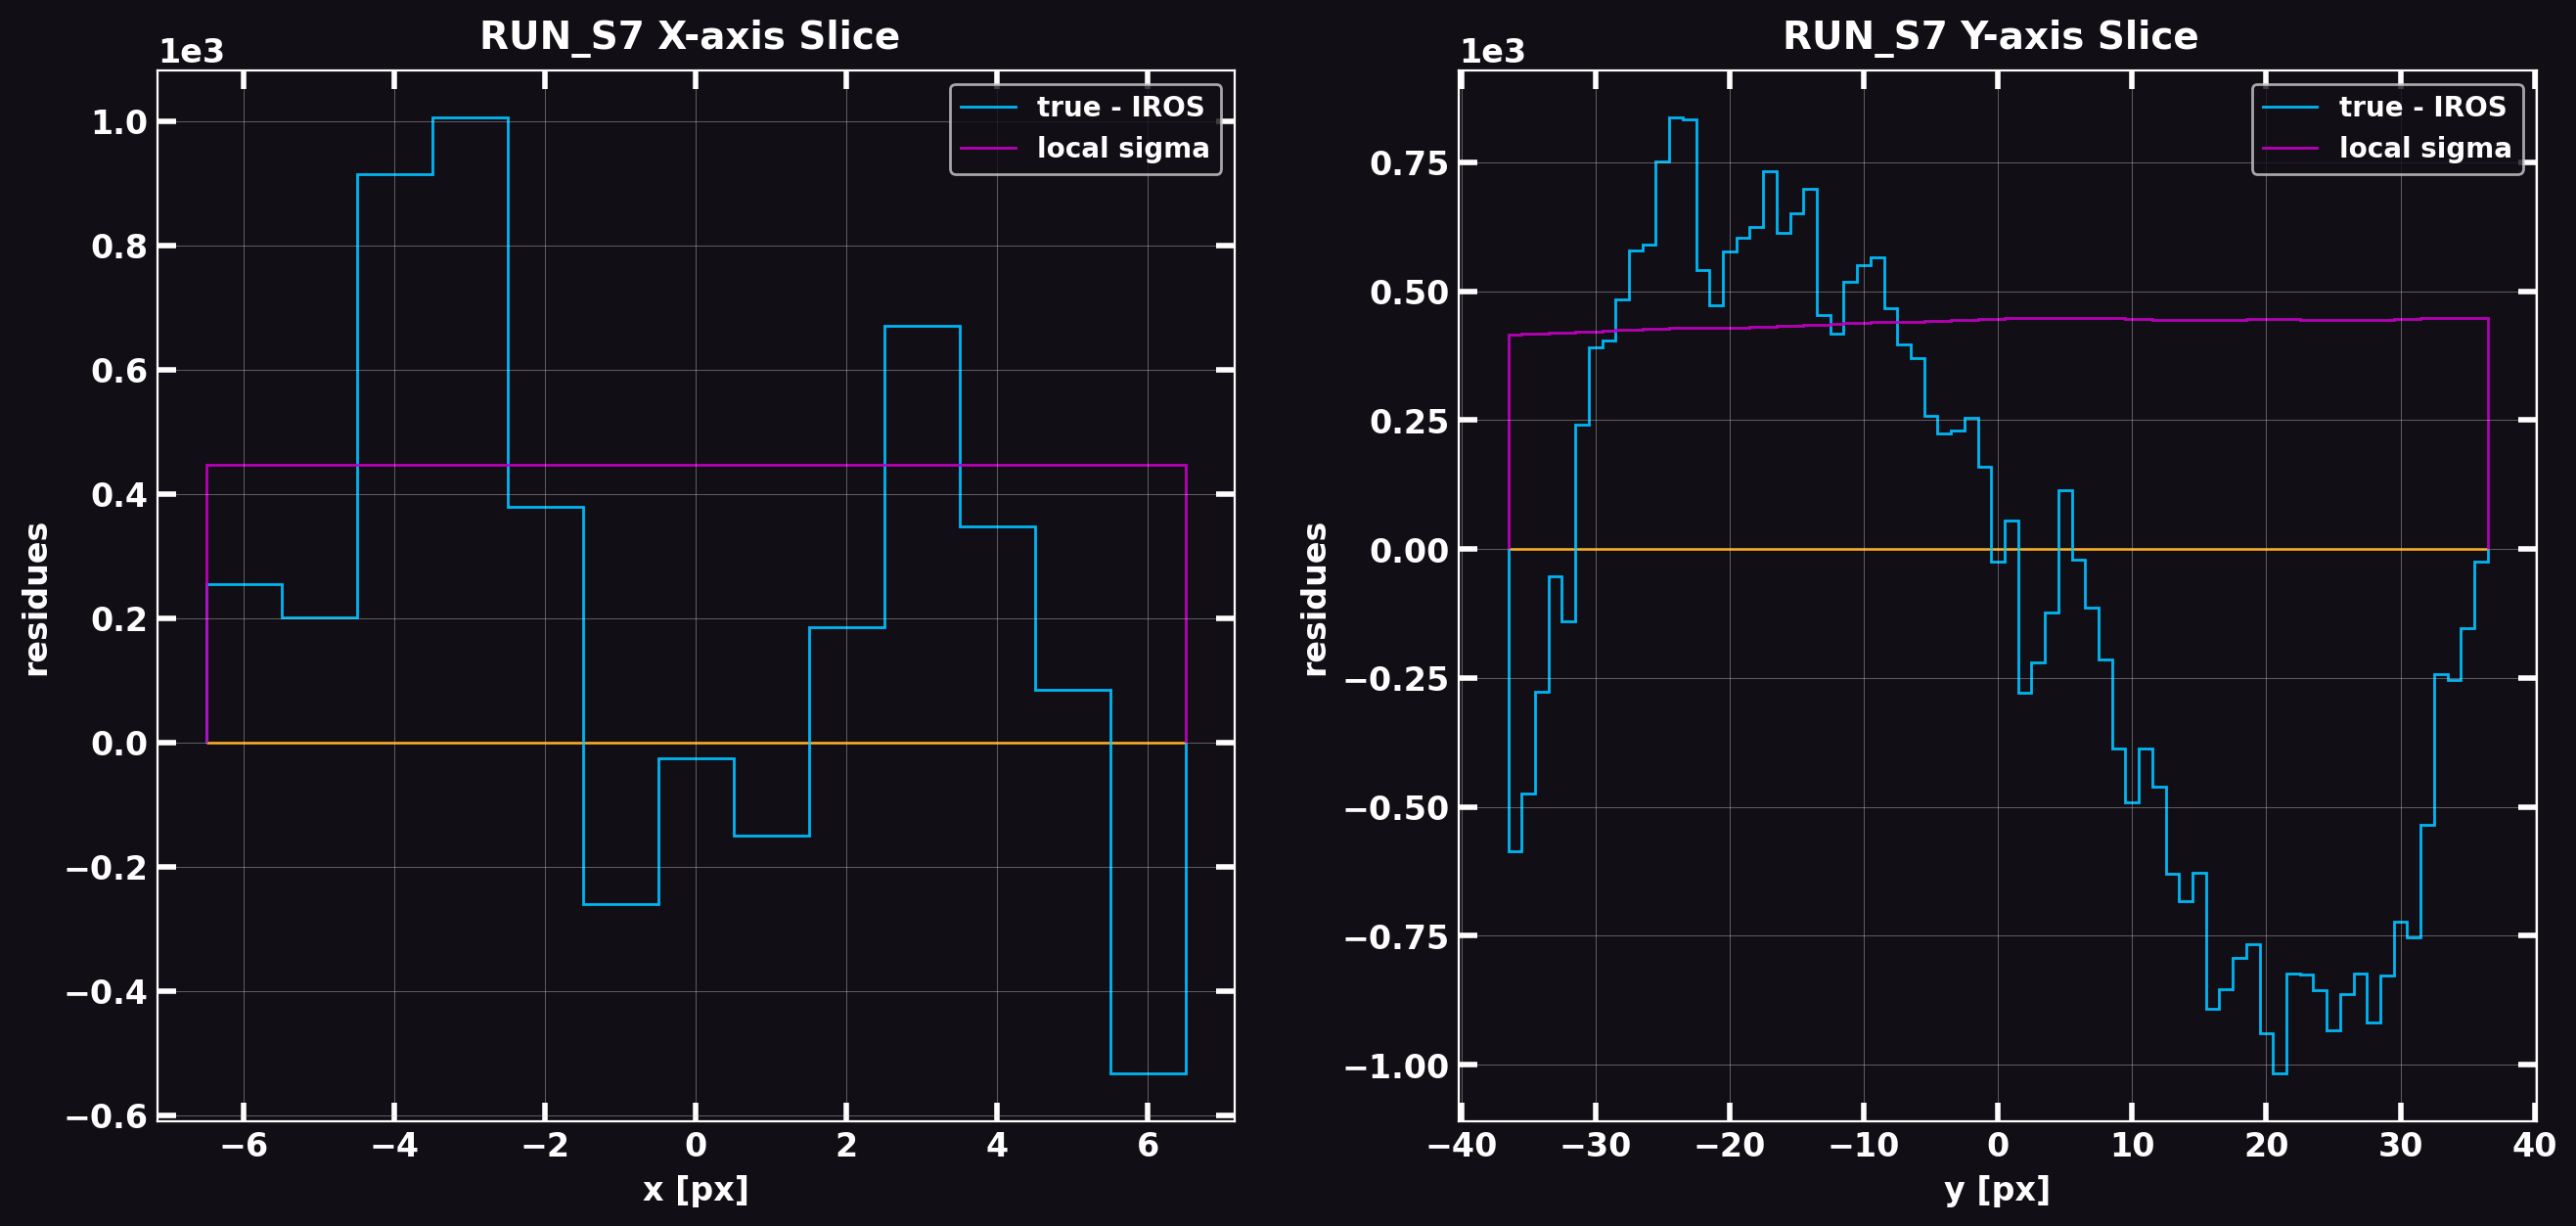

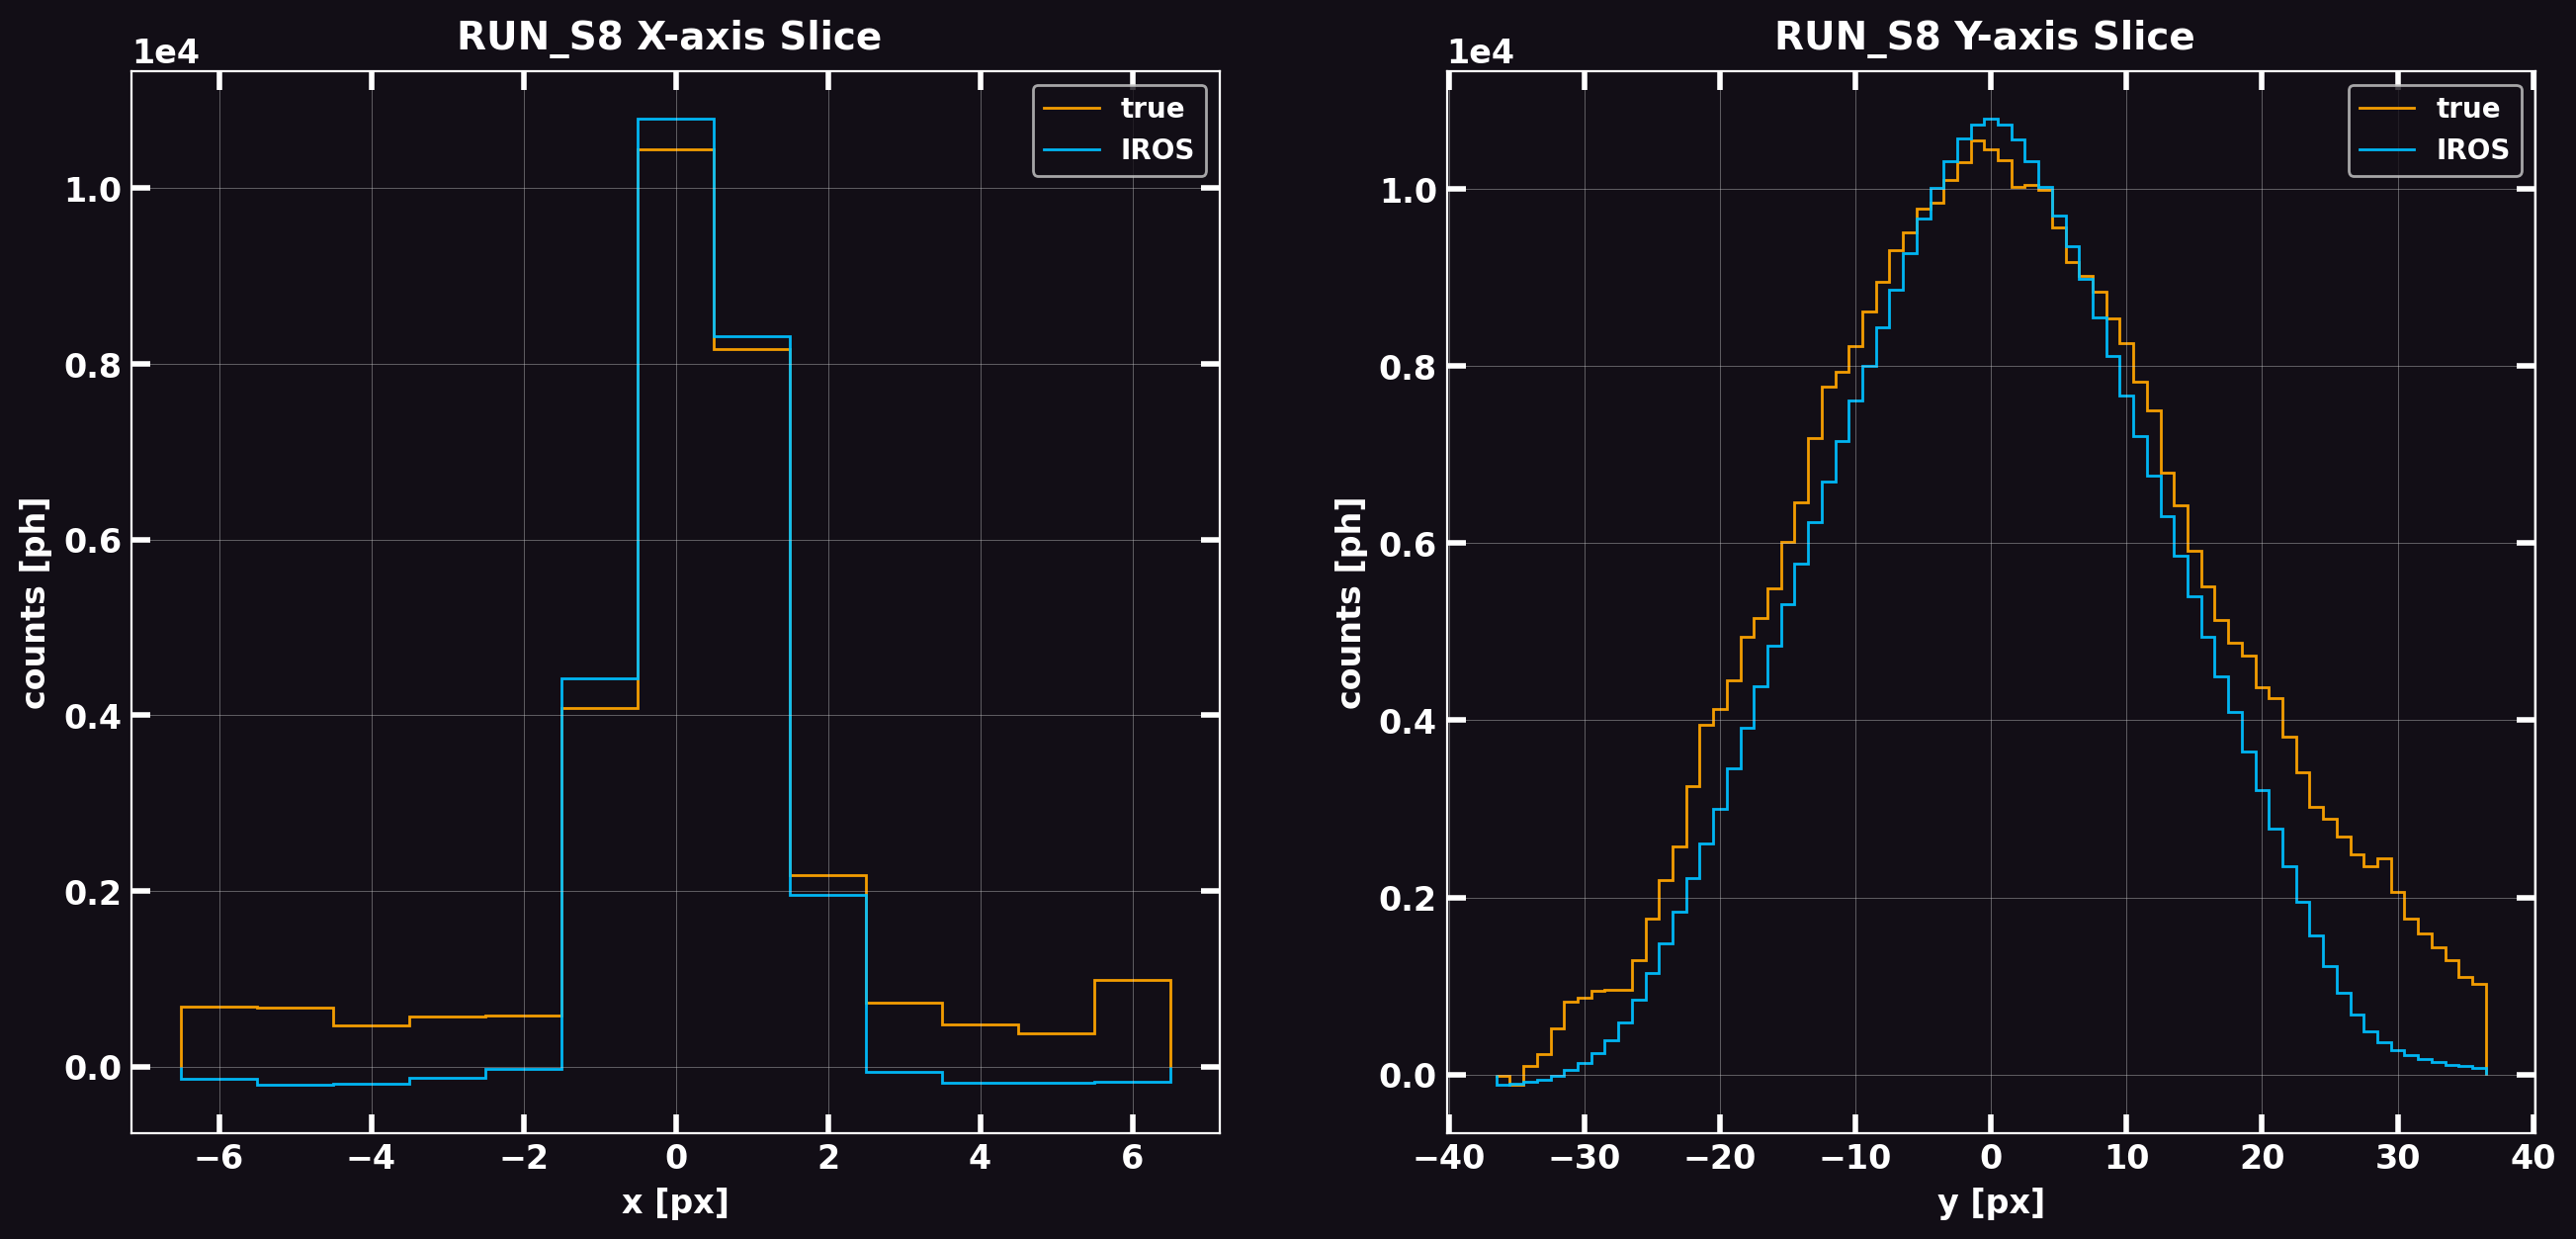

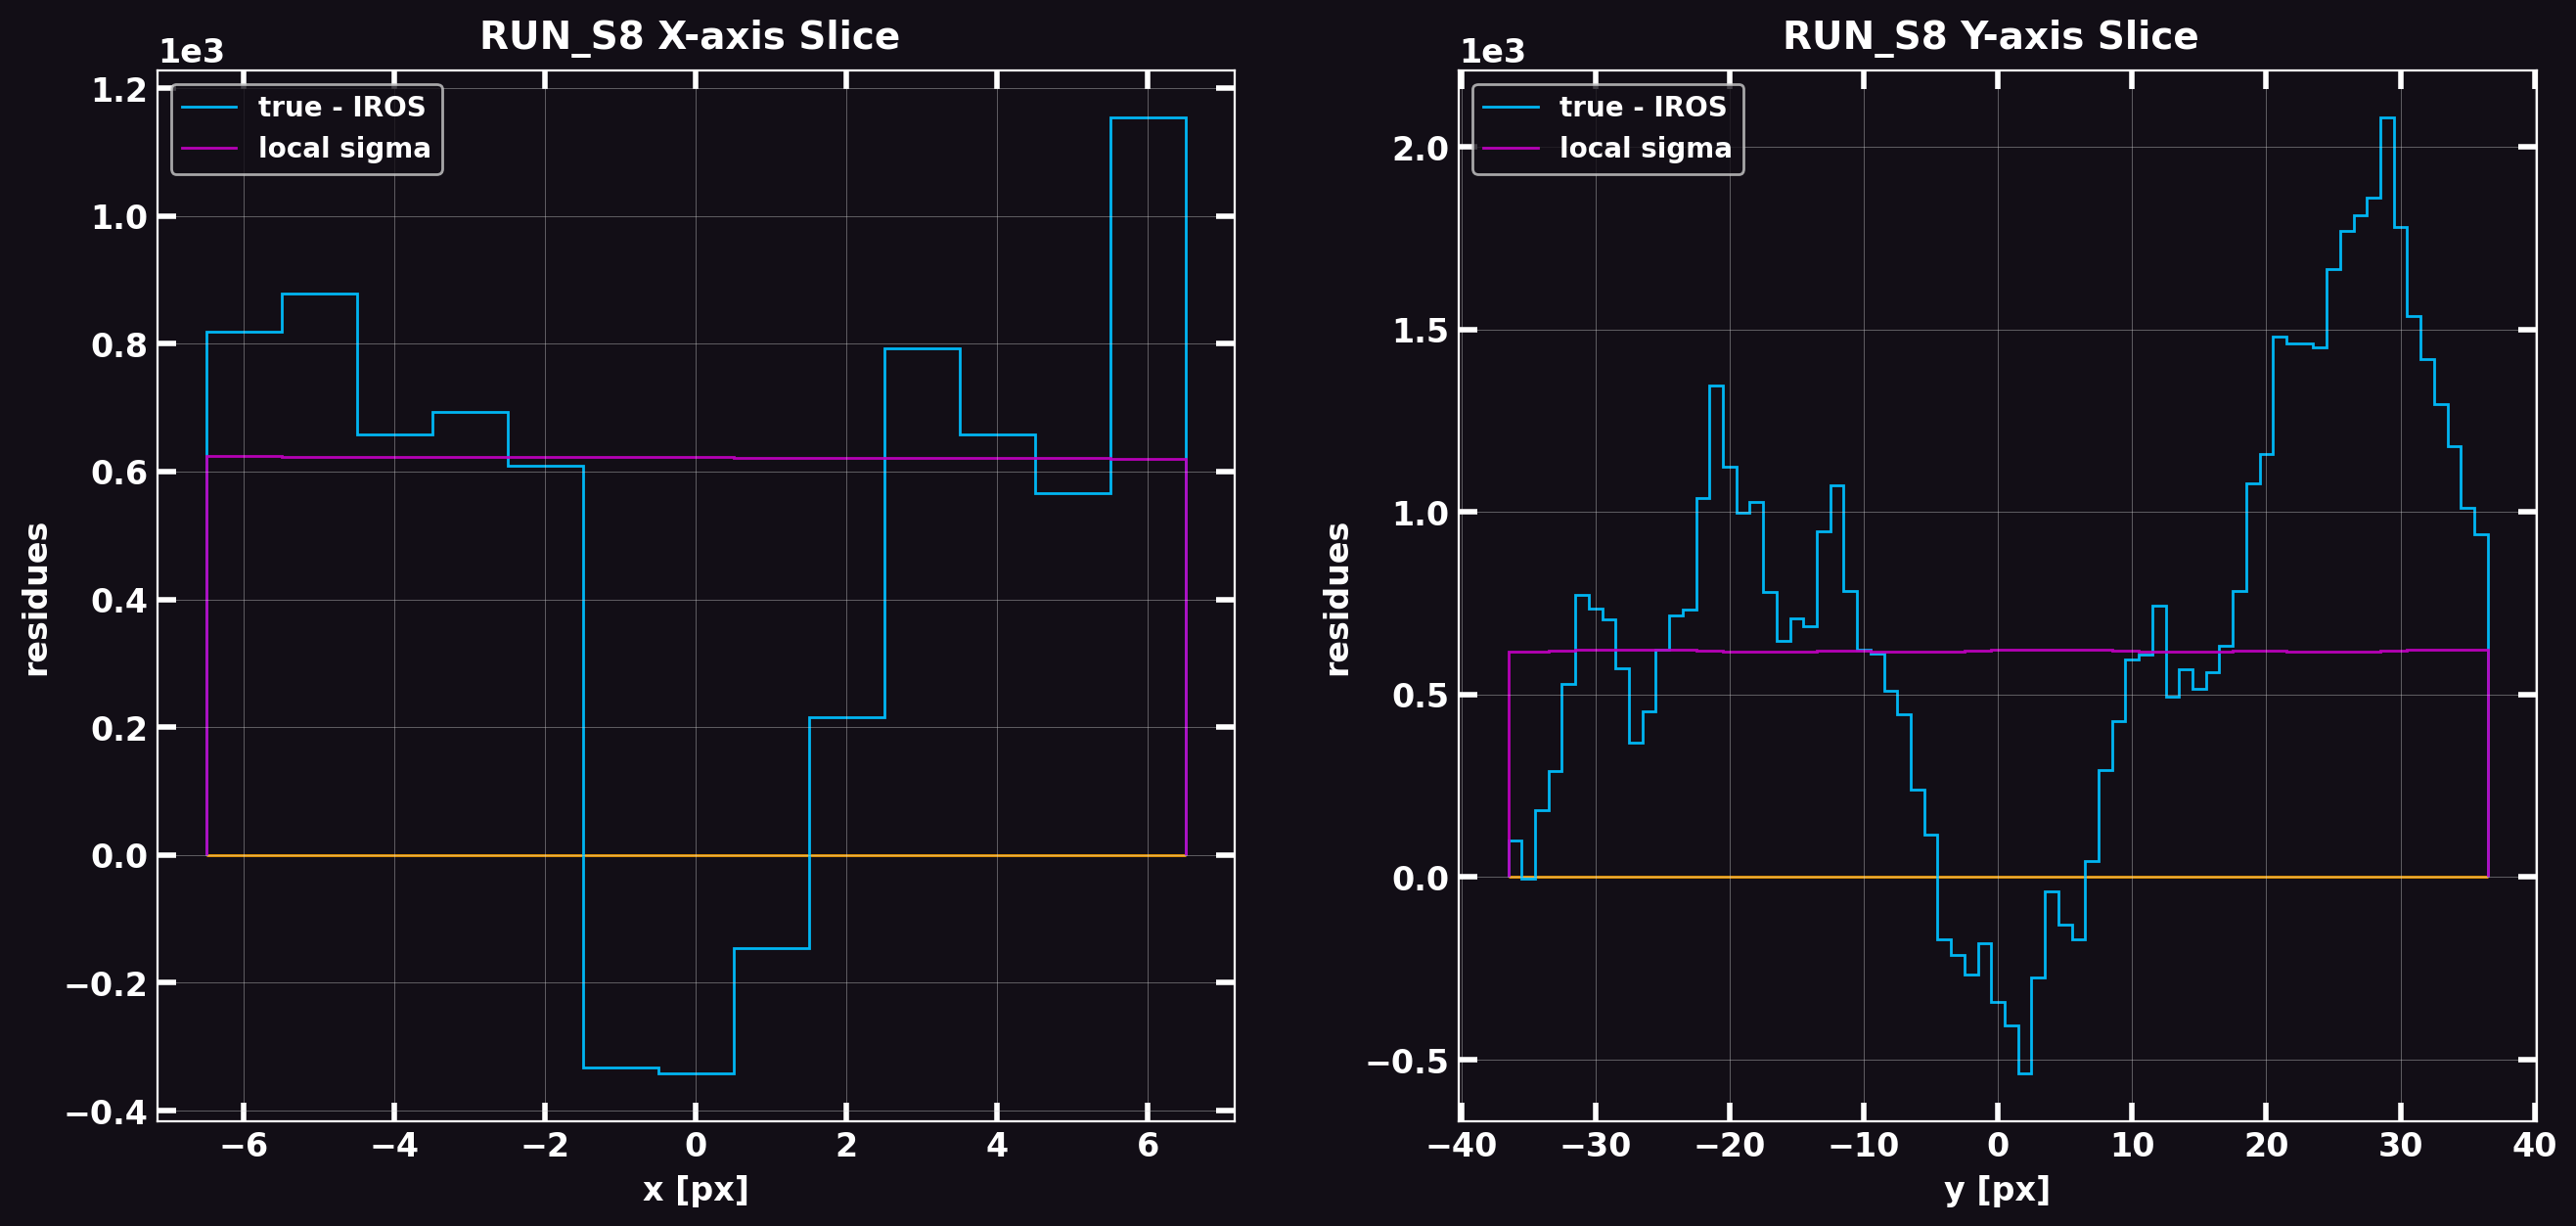

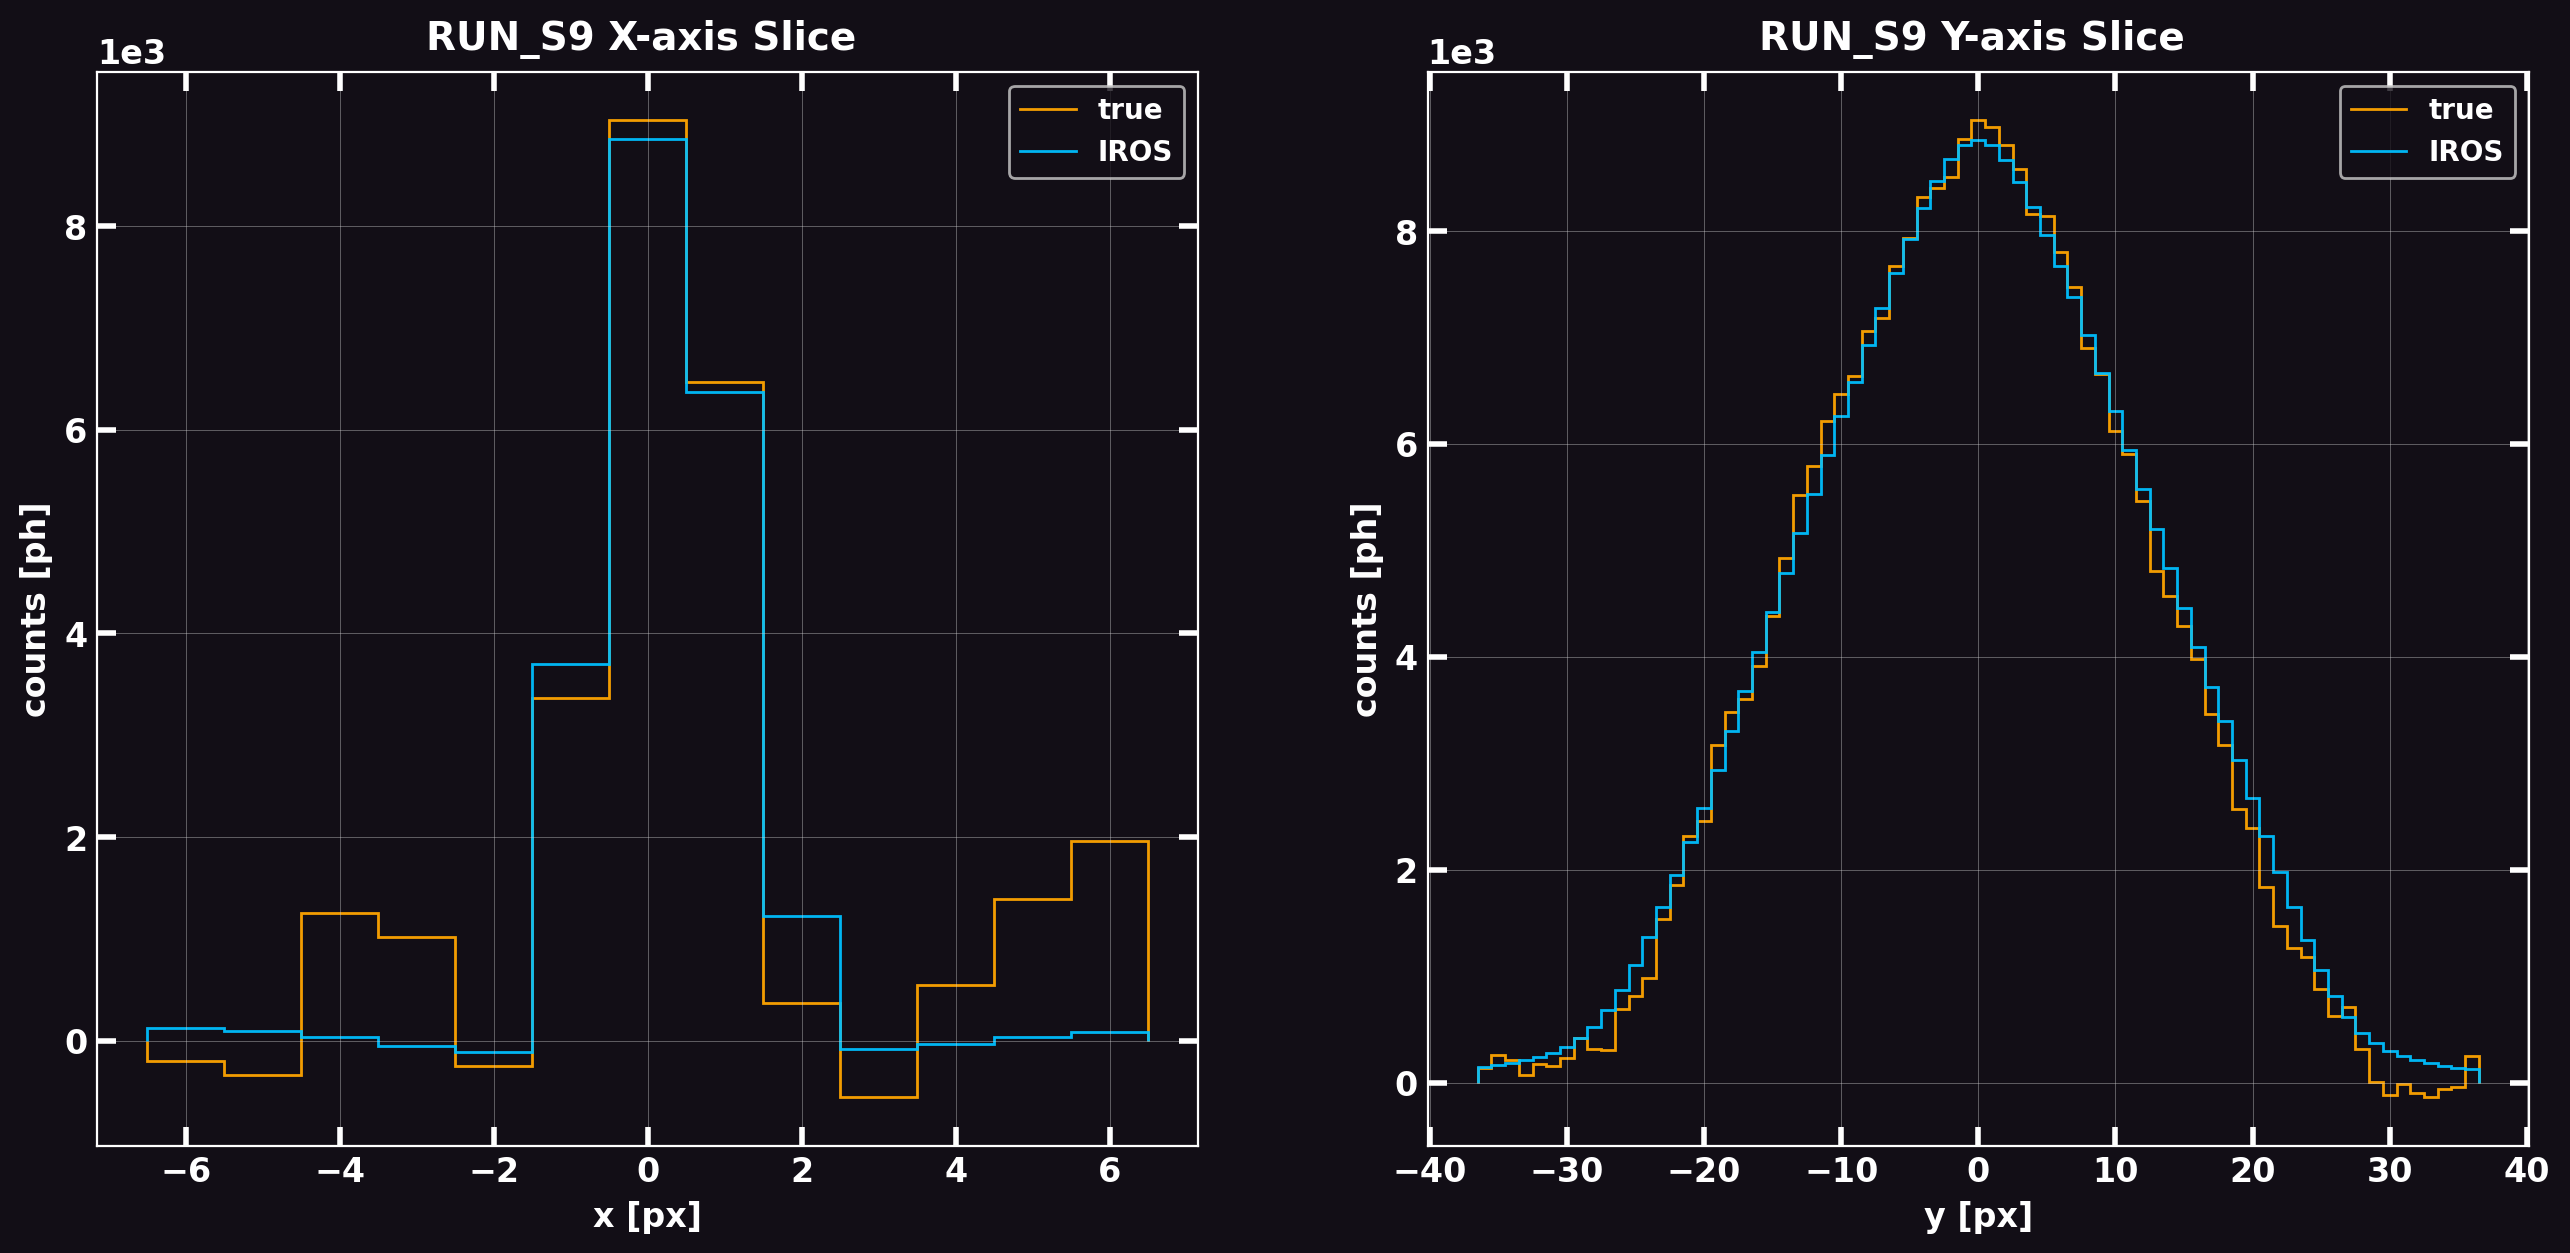

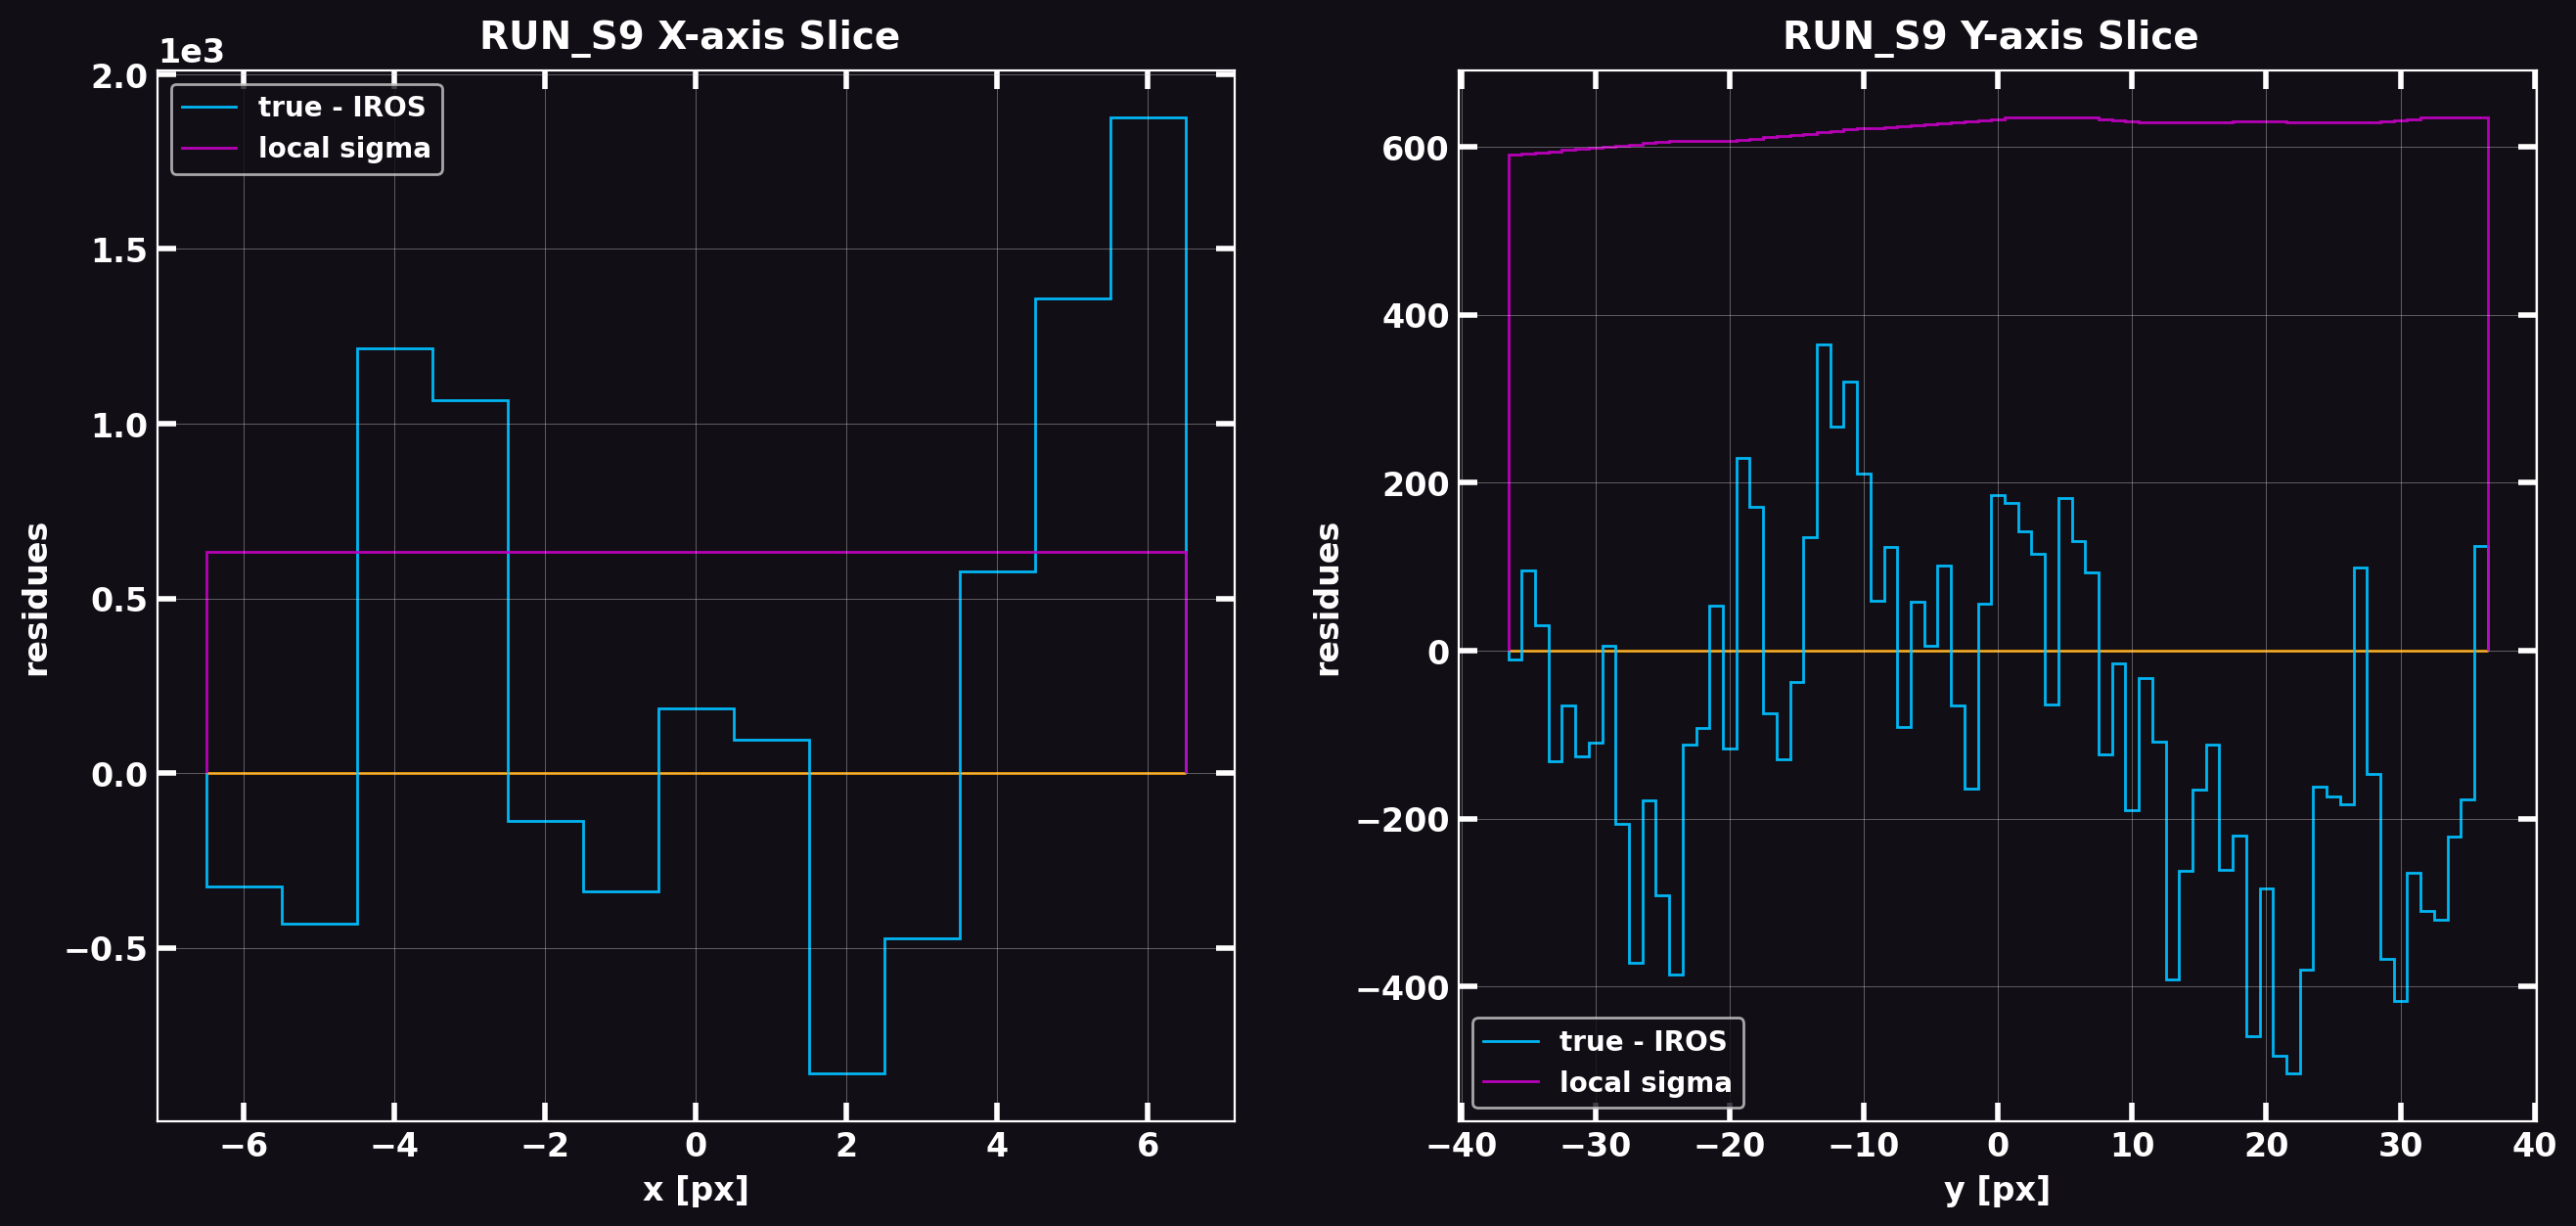

In [10]:
# WITHOUT SIGMA
from bloodmoon.mask import decode
from bloodmoon.mask import variance

true_sky: NDArray = decode(wfm, detector)
varmap: NDArray = variance(wfm, detector)

save_to = f'/home/edoardo/Desktop/IROS_{int(eband[0])}-{int(eband[1])}keV_correctVignetting_avgPsfy'
#save_to = '/mnt/d/PhD_AASS/Coding/Images_fits/IROS_8-50keV_correctVignetting_avgPsfy'
plot_results(true_sky, candidates, wfm, varmap=varmap, save_to=save_to)